# DSML Group Project — Reach for Change
## Predicting Donor Response to Optimize Outreach for Social Good

**Group Member Contribution:**
Henrique Garcia (1/3): Model Assessment, KNN, Logistic Regression

*   Henrique Garcia (1/3): Model Assessment, KNN, Logistic Regression
*   Hugo Caetano (1/3): Data Preprocessing, Decision Tree, Random Forest
*   Paulo Jorge (1/3): Feature Selection, Random Forest, Neural Network


**Abstract:**
Civic Support Alliance (CSA) is a federation representing multiple humanitarian and social aid programs and hired our team to help modernize their outreach campaign process as people's tolerance for repeated solicitations has decreased. We designed a predictive model that will help identify whether a person will donate if contacted, reducing the organization's operational costs and increasing the campaign response rates and, therefore, the return per dollar invested in outreach campaigns. The model was trained using data from 13,561 persons that have been contacted to give a donation in the past, defining them as potential future donors if they have donated in the last year's campaign (target).
With the data provided we implemented data preprocessing techniques to remove outliers, fill out the null values, and remove inconsistencies and incoherencies. That was followed by model assessment and  feature selection, which then were implemented during the testing of different models and the respective optimizations through hyperparameter tuning.
After testing different models, including KNN, Decision Tree, and Neural Network, our team concluded that the Logistic Regression is the best model for the data provided with an F1 score of 0.4 and a recall of 0.55 for the real donors (class 1). Given the class imbalance (25/75) some of the models presented bad results after training, and the others required adjustments to perform better.


<div style="background: #f0f4ff; border: 1px solid #b0c4de; border-radius: 8px; padding: 16px 20px;">

<a name='toc'></a>

## Table of Contents
- [1. Import Data](#1st-bullet)
- [2. Explore Data](#2nd-bullet)
  - [2.1 Dataset Overview](#2-1-bullet)
  - [2.2 Missing Values](#2-2-bullet)
  - [2.3 Data Quality Issues](#2-3-bullet)
  - [2.4 Target Variable & Class Imbalance](#2-4-bullet)
  - [2.5 Feature Distributions](#2-5-bullet)
- [3. Preprocess Data](#3rd-bullet)
  - [3.1 Fix Outlier](#3-1-bullet)
  - [3.2 Missing Value Imputation](#3-2-bullet)
  - [3.3 Misclassifications and Incoherencies](#3-3-bullet)
  - [3.4 Holdout split](#3-4-bullet)
- [4. Feature Selection](#4th-bullet)
  - [4.1 Categorical Variables — Chi-Square](#4-1-bullet)
  - [4.2 Numerical Variables — Variance](#4-2-bullet)
  - [4.3 Numerical Variables — Spearman Correlation](#4-3-bullet)
  - [4.4 Numerical Variables — Decision Tree Importance](#4-4-bullet)
  - [4.5 Numerical Variables — Recursive Feature Elimination](#4-5-bullet)
  - [4.6 Numerical Variables — Lasso Regularisation](#4-6-bullet)
  - [4.7 Feature Selection Summary](#4-7-bullet)
- [5. Model and Assess](#5th-bullet)
  - [5.1.1 KNN](#5-1-1-bullet)
  - [5.1.2 Logistic Regression](#5-1-2-bullet)
  - [5.1.3 Decision Tree](#5-1-3-bullet)
  - [5.1.4 Neural Network](#5-1-4-bullet)
  - [5.1.5 Randome Tree](#5-1-5-bullet)
- [6. Deploy](#6th-bullet)
- [7. Final Conclusions](#7th-bullet)

</div>

**Step 1:** Import the required libraries.

In [1]:
from pathlib import Path

import sys
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
    lab_root = Path("/content/drive/MyDrive/Colab Notebooks/DSML/Donors Project (DSML)/Part II")
else:
    lab_root = Path(".")

print(f"lab_root set to: {lab_root.resolve()}")

Mounted at /content/drive
lab_root set to: /content/drive/.shortcut-targets-by-id/1jx5EoSoCbfMb_yN6jPhHQ01zeElyOOf9/Donors Project (DSML)/Part II


In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Preprocessing & splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Feature selection
import scipy.stats as stats
from scipy.stats import chi2_contingency # filter method — categorical
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LassoCV
from scipy.stats import uniform, randint as sp_randint
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import f1_score, classification_report, confusion_matrix


import warnings
warnings.filterwarnings("once", category=FutureWarning)

In [3]:
# Shared execution configuration
RANDOM_SEED = 99
np.random.seed(RANDOM_SEED)
print(f"Configured RANDOM_SEED={RANDOM_SEED}")

Configured RANDOM_SEED=99


<a class="anchor" id="1st-bullet"></a>

# 1. Import Data
Load the descriptive features and the target variable, then merge them on `CONTROL_NUMBER`.

**Step 2:** Load the training feature set and the target variable. Merge on `CONTROL_NUMBER` and set it as the index.

In [4]:
data_path     = lab_root / "data/donors_descriptive.csv"
target_path   = lab_root / "data/donors_train_target.csv"
test_path     = lab_root / "data/test.csv"

if not data_path.exists():
    raise FileNotFoundError(f"Feature file not found: {data_path}")
if not target_path.exists():
    raise FileNotFoundError(f"Target file not found: {target_path}")

descriptive = pd.read_csv(data_path)
target      = pd.read_csv(target_path)
testing    = pd.read_csv(test_path)

training = descriptive.merge(target, on="CONTROL_NUMBER").set_index("CONTROL_NUMBER")
testing = testing.set_index("CONTROL_NUMBER")

print(f"Training set : {training.shape[0]:,} rows × {training.shape[1]} columns")
print(f"Test set     : {testing.shape[0]:,} rows × {testing.shape[1]} columns")
training.head()

Training set : 13,560 rows × 40 columns
Test set     : 5,812 rows × 39 columns


,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,9.0,...,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN,1
112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,6.0,...,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN,1
166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,17.0,...,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN,0
170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,28.0,...,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN,0
44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,9.0,...,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN,0


In [5]:
# Merge training and testing datasets with label
training['DATA_TYPE'] = 'training'
testing['DATA_TYPE'] = 'testing'

data = pd.concat([training, testing], axis=0)
data

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B,DATA_TYPE
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
61745,4.000000,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,9.0,...,0.0,0.000,2.0,0.154,0.0,2,T,NaN,1.0,training
112703,3.000000,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,6.0,...,1.0,0.250,1.0,0.100,0.0,3,R,NaN,1.0,training
166437,4.000000,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,17.0,...,0.0,0.000,3.0,0.231,1.0,1,U,NaN,0.0,training
170621,4.000000,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,28.0,...,2.0,0.286,2.0,0.111,0.0,1,U,NaN,0.0,training
44428,6.000000,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,9.0,...,3.0,0.600,5.0,0.500,0.0,2,C,NaN,0.0,training
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54438,6.000000,0.000000,27.0,M,5.0,1.0,U,4.0,17.0,NaN,...,2.0,0.200,2.0,0.095,13.0,2,R,8.0,NaN,testing
122194,6.000000,1.000000,42.0,M,3.0,2.0,H,7.0,20.0,11.0,...,3.0,0.429,3.0,0.214,0.0,1,C,NaN,NaN,testing
106603,2.136786,0.000000,81.0,F,8.0,3.0,H,2.0,10.0,21.0,...,NaN,0.400,5.0,0.238,0.0,3,T,NaN,NaN,testing


In [6]:
testing.head()

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,DATA_TYPE
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
122653,5.0,0.0,72.0,M,1.0,1.0,H,4.0,25.0,13.000000,...,25.00,0.0,0.789208,1.0,0.071,0.0,2,T,NaN,testing
184239,5.0,3.0,73.0,U,20.0,4.0,U,NaN,6.0,32.000000,...,4.63,6.0,0.545000,8.0,0.421,1.0,2,C,1.0,testing
5172,6.0,2.0,36.0,M,11.0,NaN,H,4.0,10.0,44.352712,...,16.00,1.0,0.125000,2.0,0.111,1.0,3,R,1.0,testing
135377,6.0,3.0,NaN,F,2.0,4.0,U,2.0,10.0,9.000000,...,8.25,2.0,0.400000,4.0,0.364,0.0,1,U,NaN,testing
62119,6.0,0.0,83.0,F,9.0,2.0,U,2.0,20.0,31.000000,...,20.00,1.0,0.125000,2.0,NaN,1.0,2,T,5.0,testing


In [7]:
target.head()

,CONTROL_NUMBER,TARGET_B
0,61745,1
1,112703,1
2,166437,0
3,170621,0
4,44428,0


<a class="anchor" id="2nd-bullet"></a>

# 2. Explore Data
Inspect the dataset before making any changes. The goal of this section is to understand the data quality, spot anomalies, and gather evidence that will justify every preprocessing decision made later.

<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

<a class="anchor" id="2-1-bullet"></a>

## 2.1. Dataset Overview

</div>

**Step 3:** Review the dataset structure using `info()` to confirm data types and spot columns that pandas did not infer as numeric, and `describe()`to ahve a sense of each variable's distribution.

In [8]:
training.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13560 entries, 61745 to 45722
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CARD_PROM_12                 13297 non-null  float64
 1   CHILDREN                     13289 non-null  float64
 2   DONOR_AGE                    9970 non-null   float64
 3   DONOR_GENDER                 13303 non-null  object 
 4   FILE_CARD_GIFT               13292 non-null  float64
 5   FREQUENCY_STATUS_97NK        13296 non-null  float64
 6   HOME_OWNER                   13292 non-null  object 
 7   INCOME_GROUP                 10273 non-null  float64
 8   LAST_GIFT_AMT                13296 non-null  float64
 9   LIFETIME_CARD_PROM           13289 non-null  float64
 10  LIFETIME_GIFT_AMOUNT         13288 non-null  float64
 11  LIFETIME_GIFT_COUNT          13304 non-null  float64
 12  LIFETIME_MAX_GIFT_AMT        13284 non-null  float64
 13  LIFETIME_MIN_GIFT

In [9]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
CARD_PROM_12,18987.0,5.368309,1.305256,0.000000,5.000,6.000,6.000,17.000000
CHILDREN,18986.0,2.006935,1.476945,-2.341107,1.000,2.000,3.000,6.264709
DONOR_AGE,14326.0,58.936739,17.547494,0.000000,47.000,60.000,73.000,108.934261
FILE_CARD_GIFT,18989.0,5.260001,4.816473,-10.100341,2.000,4.000,8.000,41.000000
FREQUENCY_STATUS_97NK,18988.0,1.984775,1.144329,-1.365242,1.000,2.000,3.000,5.283869
INCOME_GROUP,14729.0,3.902481,1.957224,-1.728999,2.000,4.000,5.000,9.490799
LAST_GIFT_AMT,18987.0,16.567679,12.529328,-21.718664,10.000,15.000,20.000,450.000000
LIFETIME_CARD_PROM,18989.0,18.668583,8.901940,-7.188999,11.000,18.000,26.000,56.000000
LIFETIME_GIFT_AMOUNT,18986.0,104.519981,111.109261,-245.473199,41.000,79.000,132.000,3775.000000
LIFETIME_GIFT_COUNT,18989.0,9.957463,9.071666,-18.583020,4.000,8.000,14.000,95.000000


**Step 4:** Identify each predictor's type before choosing a feature-selection method, since the appropriate method depends on the variable type.

| Predictor | Type | Notes |
| --- | --- | --- |
| DONOR_GENDER | Categorical | F / M / U |
| HOME_OWNER | Categorical | H / U |
| RECENCY_STATUS_96NK | Categorical | A / E / F / L / N / S — recency tier |
| SES | Categorical (ordinal) | 1–4 + '?' entries |
| URBANICITY | Categorical | C / R / S / T / U + '?' entries |
| CARD_PROM_12 | Continuous | |
| CHILDREN | Continuous | |
| DONOR_AGE | Continuous | 26.5% missing |
| FILE_CARD_GIFT | Continuous | |
| FREQUENCY_STATUS_97NK | Continuous | Contains corrupt float values |
| INCOME_GROUP | Continuous | 24.2% missing |
| LAST_GIFT_AMT | Continuous | Contains negative values |
| LIFETIME_* | Continuous | Lifetime donation history features |
| MEDIAN_HOME_VALUE | Continuous | Census area feature |
| MEDIAN_HOUSEHOLD_INCOME | Continuous | Census area feature |
| MONTHS_SINCE_* | Continuous | Recency features |
| NUMBER_PROM_12 | Continuous | |
| PCT_ATTRIBUTE1–4 | Continuous | Area-level percentage features |
| PCT_OWNER_OCCUPIED | Continuous | Census area feature |
| PEP_STAR | Binary | |
| PER_CAPITA_INCOME | Continuous | Census area feature |
| RECENT_* | Continuous | Recent campaign behaviour features |
| WEALTH_RATING | Continuous | 46.2% missing |
| — | — | — |
| TARGET_B | Binary target | 1 = donated, 0 = did not donate |

<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

<a class="anchor" id="2-2-bullet"></a>

## 2.2. Missing Values

</div>

**Step 5:** Compute the percentage of missing values per column and highlight the three features with substantial missingness.

In [10]:
missing = (data.isnull().mean() * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ["Feature", "Missing (%)"]

print(missing_df.to_string(index=False))

                    Feature  Missing (%)
              WEALTH_RATING    46.138757
                   TARGET_B    30.002065
                  DONOR_AGE    26.047904
               INCOME_GROUP    23.967582
MONTHS_SINCE_LAST_PROM_RESP     3.205658
        RECENCY_STATUS_96NK     1.997729
                 HOME_OWNER     1.997729
               DONOR_GENDER     1.997729
                        SES     1.997729
                 URBANICITY     1.997729
  RECENT_CARD_RESPONSE_PROP     1.992567
        RECENT_AVG_GIFT_AMT     1.992567
       LIFETIME_GIFT_AMOUNT     1.992567
                   CHILDREN     1.992567
   RECENT_AVG_CARD_GIFT_AMT     1.987405
              LAST_GIFT_AMT     1.987405
               CARD_PROM_12     1.987405
         RECENT_STAR_STATUS     1.987405
      RECENT_RESPONSE_COUNT     1.987405
             PCT_ATTRIBUTE4     1.987405
      FREQUENCY_STATUS_97NK     1.982242
         PCT_OWNER_OCCUPIED     1.982242
    MONTHS_SINCE_FIRST_GIFT     1.982242
    MEDIAN_HOUSE

**Conclusion:** Three features have substantial missingness (ignoring `TARGET_B`):
- `WEALTH_RATING`: 46.1% missing — too high to impute without acknowledging it. We will drop this variable later on.
- `DONOR_AGE`: 26% missing — will will inputer using random samplings intead of the median since it's a relatively high number of missing values.
- `INCOME_GROUP`: 24% missing — we use other variables related to income and wealth to poulate its missing values.

<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

<a class="anchor" id="2-3-bullet"></a>

## 2.3. Data Quality Issues

</div>

**Step 6:** Inspect the categorical columns for non-standard entries that will not be caught by `isnull()`.

In [11]:
cat_cols = ["DONOR_GENDER", "HOME_OWNER", "RECENCY_STATUS_96NK", "SES", "URBANICITY"]
for col in cat_cols:
    print(f"{col}: {data[col].value_counts().to_dict()}")

DONOR_GENDER: {'F': 10209, 'M': 7778, 'U': 998}
HOME_OWNER: {'H': 10394, 'U': 8591}
RECENCY_STATUS_96NK: {'A': 11691, 'S': 4121, 'F': 1493, 'N': 1166, 'E': 421, 'L': 93}
SES: {'2': 9099, '1': 5807, '3': 3266, '?': 439, '4': 374}
URBANICITY: {'S': 4394, 'C': 3938, 'R': 3934, 'T': 3868, 'U': 2407, '?': 444}


**Conclusion:** `SES` and `URBANICITY` both contain `'?'` entries (439 and 444 respectively). These are not NaN and will not be caught by standard missing-value checks. They must be replaced with `np.nan` before imputation.

**Step 7:** Inspect numeric varibales with negative values.

In [12]:
# Get the number of negative values for each numeric variable
negative_counts = (data.select_dtypes(include='number') < 0).sum()
negative_df = negative_counts[negative_counts > 0].reset_index()
negative_df.columns = ['Feature', 'Negative Count']

print(negative_df.to_string(index=False))

                    Feature  Negative Count
                   CHILDREN              96
             FILE_CARD_GIFT              96
      FREQUENCY_STATUS_97NK              96
               INCOME_GROUP              96
              LAST_GIFT_AMT              96
         LIFETIME_CARD_PROM              96
       LIFETIME_GIFT_AMOUNT              96
        LIFETIME_GIFT_COUNT              96
      LIFETIME_MAX_GIFT_AMT              96
      LIFETIME_MIN_GIFT_AMT              96
              LIFETIME_PROM              96
          MEDIAN_HOME_VALUE              96
    MEDIAN_HOUSEHOLD_INCOME              96
    MONTHS_SINCE_FIRST_GIFT              96
MONTHS_SINCE_LAST_PROM_RESP               8
             NUMBER_PROM_12              96
             PCT_ATTRIBUTE1              96
             PCT_ATTRIBUTE2              96
             PCT_ATTRIBUTE3              96
             PCT_ATTRIBUTE4              96
                   PEP_STAR              96
          PER_CAPITA_INCOME     

In [13]:
# See the records with at least a negative value
data[data.select_dtypes(include='number').lt(0).any(axis=1)]

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B,DATA_TYPE
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
112703,3.0,-2.341107,NaN,F,1.0,1.000000,U,NaN,15.0,6.0,...,1.0,0.250000,1.000000,0.100,0.000000,3,R,NaN,1.0,training
81374,6.0,1.000000,51.0,M,5.0,-1.365242,U,2.0,12.0,21.0,...,1.0,0.111000,3.000000,NaN,1.000000,3,R,2.0,0.0,training
3160,6.0,1.000000,87.0,F,3.0,2.000000,H,4.0,25.0,19.0,...,2.0,-0.369805,3.000000,0.158,0.000000,1,S,7.0,0.0,training
21878,6.0,3.000000,56.0,M,3.0,1.000000,H,6.0,15.0,22.0,...,1.0,0.111000,3.000000,0.150,0.000000,2,T,0.0,0.0,training
172329,5.0,0.000000,61.0,F,1.0,3.000000,U,1.0,11.0,NaN,...,1.0,0.250000,3.000000,0.300,0.000000,3,C,NaN,0.0,training
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112217,6.0,1.000000,NaN,F,2.0,1.000000,U,NaN,10.0,12.0,...,2.0,0.400000,3.000000,0.200,0.000000,2,T,7.0,NaN,testing
156877,4.0,4.000000,84.0,M,0.0,1.000000,U,1.0,20.0,7.0,...,0.0,0.000000,1.000000,0.083,0.000000,1,U,NaN,NaN,testing
105371,6.0,0.000000,65.0,U,11.0,3.000000,U,NaN,20.0,29.0,...,1.0,0.091000,3.000000,0.136,-7.806416,3,R,2.0,NaN,testing


**Conclusion:** None of our numeric variables should have negative values since they reflect number of campaigns, donations, months, frequecies, children, proportions, percentages, and others like ratings and status. Even though there's a consistent number of negative records across most of the variables (96), they are related to different donors for a total of 2594 records.

<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

<a class="anchor" id="2-4-bullet"></a>

## 2.4. Target Variable & Class Imbalance

</div>

**Step 8:** Examine the distribution of `TARGET_B` and understand the class imbalance.

Class distribution:
TARGET_B
0.0    10170
1.0     3390
Name: count, dtype: int64

Donation rate : 25.00%
Class ratio   : 3.0:1  (non-donors to donors)


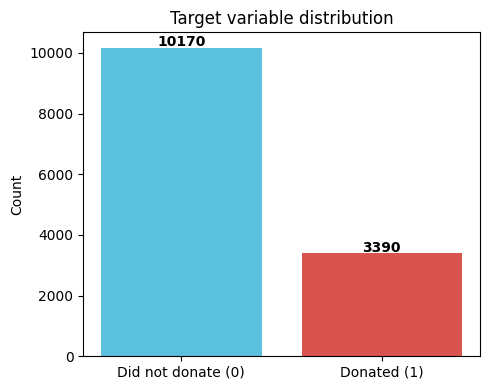

In [14]:
train_data = data[data['DATA_TYPE'] == 'training']

target_counts = train_data["TARGET_B"].value_counts()
print("Class distribution:")
print(target_counts)
print(f"\nDonation rate : {train_data['TARGET_B'].mean():.2%}")
print(f"Class ratio   : {target_counts[0] / target_counts[1]:.1f}:1  (non-donors to donors)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Did not donate (0)", "Donated (1)"], target_counts.values,
       color=["#5bc0de", "#d9534f"])
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 50, str(v), ha="center", fontweight="bold")
ax.set_ylabel("Count")
ax.set_title("Target variable distribution")
plt.tight_layout()
plt.show()

**Conclusion:** The dataset is imbalanced at a 3:1 ratio (10,170 non-donors vs 3,390 donors). A naive classifier that predicts no one donates achieves 75% accuracy but an F1 score of 0.0 — completely uninformative. A classifier that predicts everyone donates achieves an F1 of 0.40, which is the effective Kaggle baseline to beat. All models must use `class_weight='balanced'` or equivalent to avoid collapsing to the majority class.

**Step 9:** Examine donation rates across the categorical features to identify which categories are most predictive.

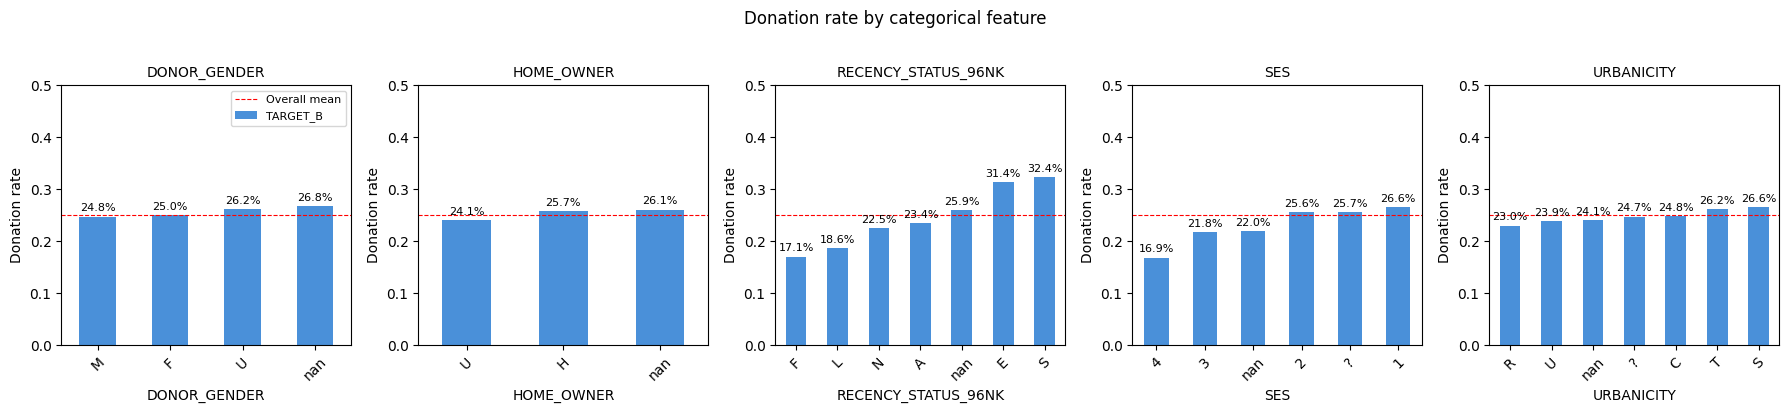

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
cat_cols_plot = ["DONOR_GENDER", "HOME_OWNER", "RECENCY_STATUS_96NK", "SES", "URBANICITY"]

for ax, col in zip(axes, cat_cols_plot):
    rates = train_data.groupby(col, dropna=False)["TARGET_B"].mean().sort_values()
    rates.plot(kind="bar", ax=ax, color="#4a90d9")
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Donation rate")
    ax.set_ylim(0, 0.5)
    ax.tick_params(axis="x", rotation=45)
    ax.axhline(train_data["TARGET_B"].mean(), color="red", linestyle="--",
               linewidth=0.8, label="Overall mean")
    for i, v in enumerate(rates):
        ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=8)

axes[0].legend(fontsize=8)
plt.suptitle("Donation rate by categorical feature", y=1.02)
plt.tight_layout()
plt.show()

**Conclusion:** `RECENCY_STATUS_96NK` shows the most meaningful variation — statuses `S` (lapsed, 32.4%) and `E` (31.4%) donate at nearly double the rate of `F` (first-time, 17.1%). The other categorical features show limited differentiation across their levels.

<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

<a class="anchor" id="2-5-bullet"></a>

## 2.5. Feature Distributions

</div>

**Step 10:** Compare the distribution ofnnumerical features between donors and non-donors to surface early signals, calculating the percentage of overlapping between the two distributions for each variable.

/tmp/ipykernel_133833/3067641434.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  overlap = np.trapz(np.minimum(kde_donors, kde_non_donors), x)


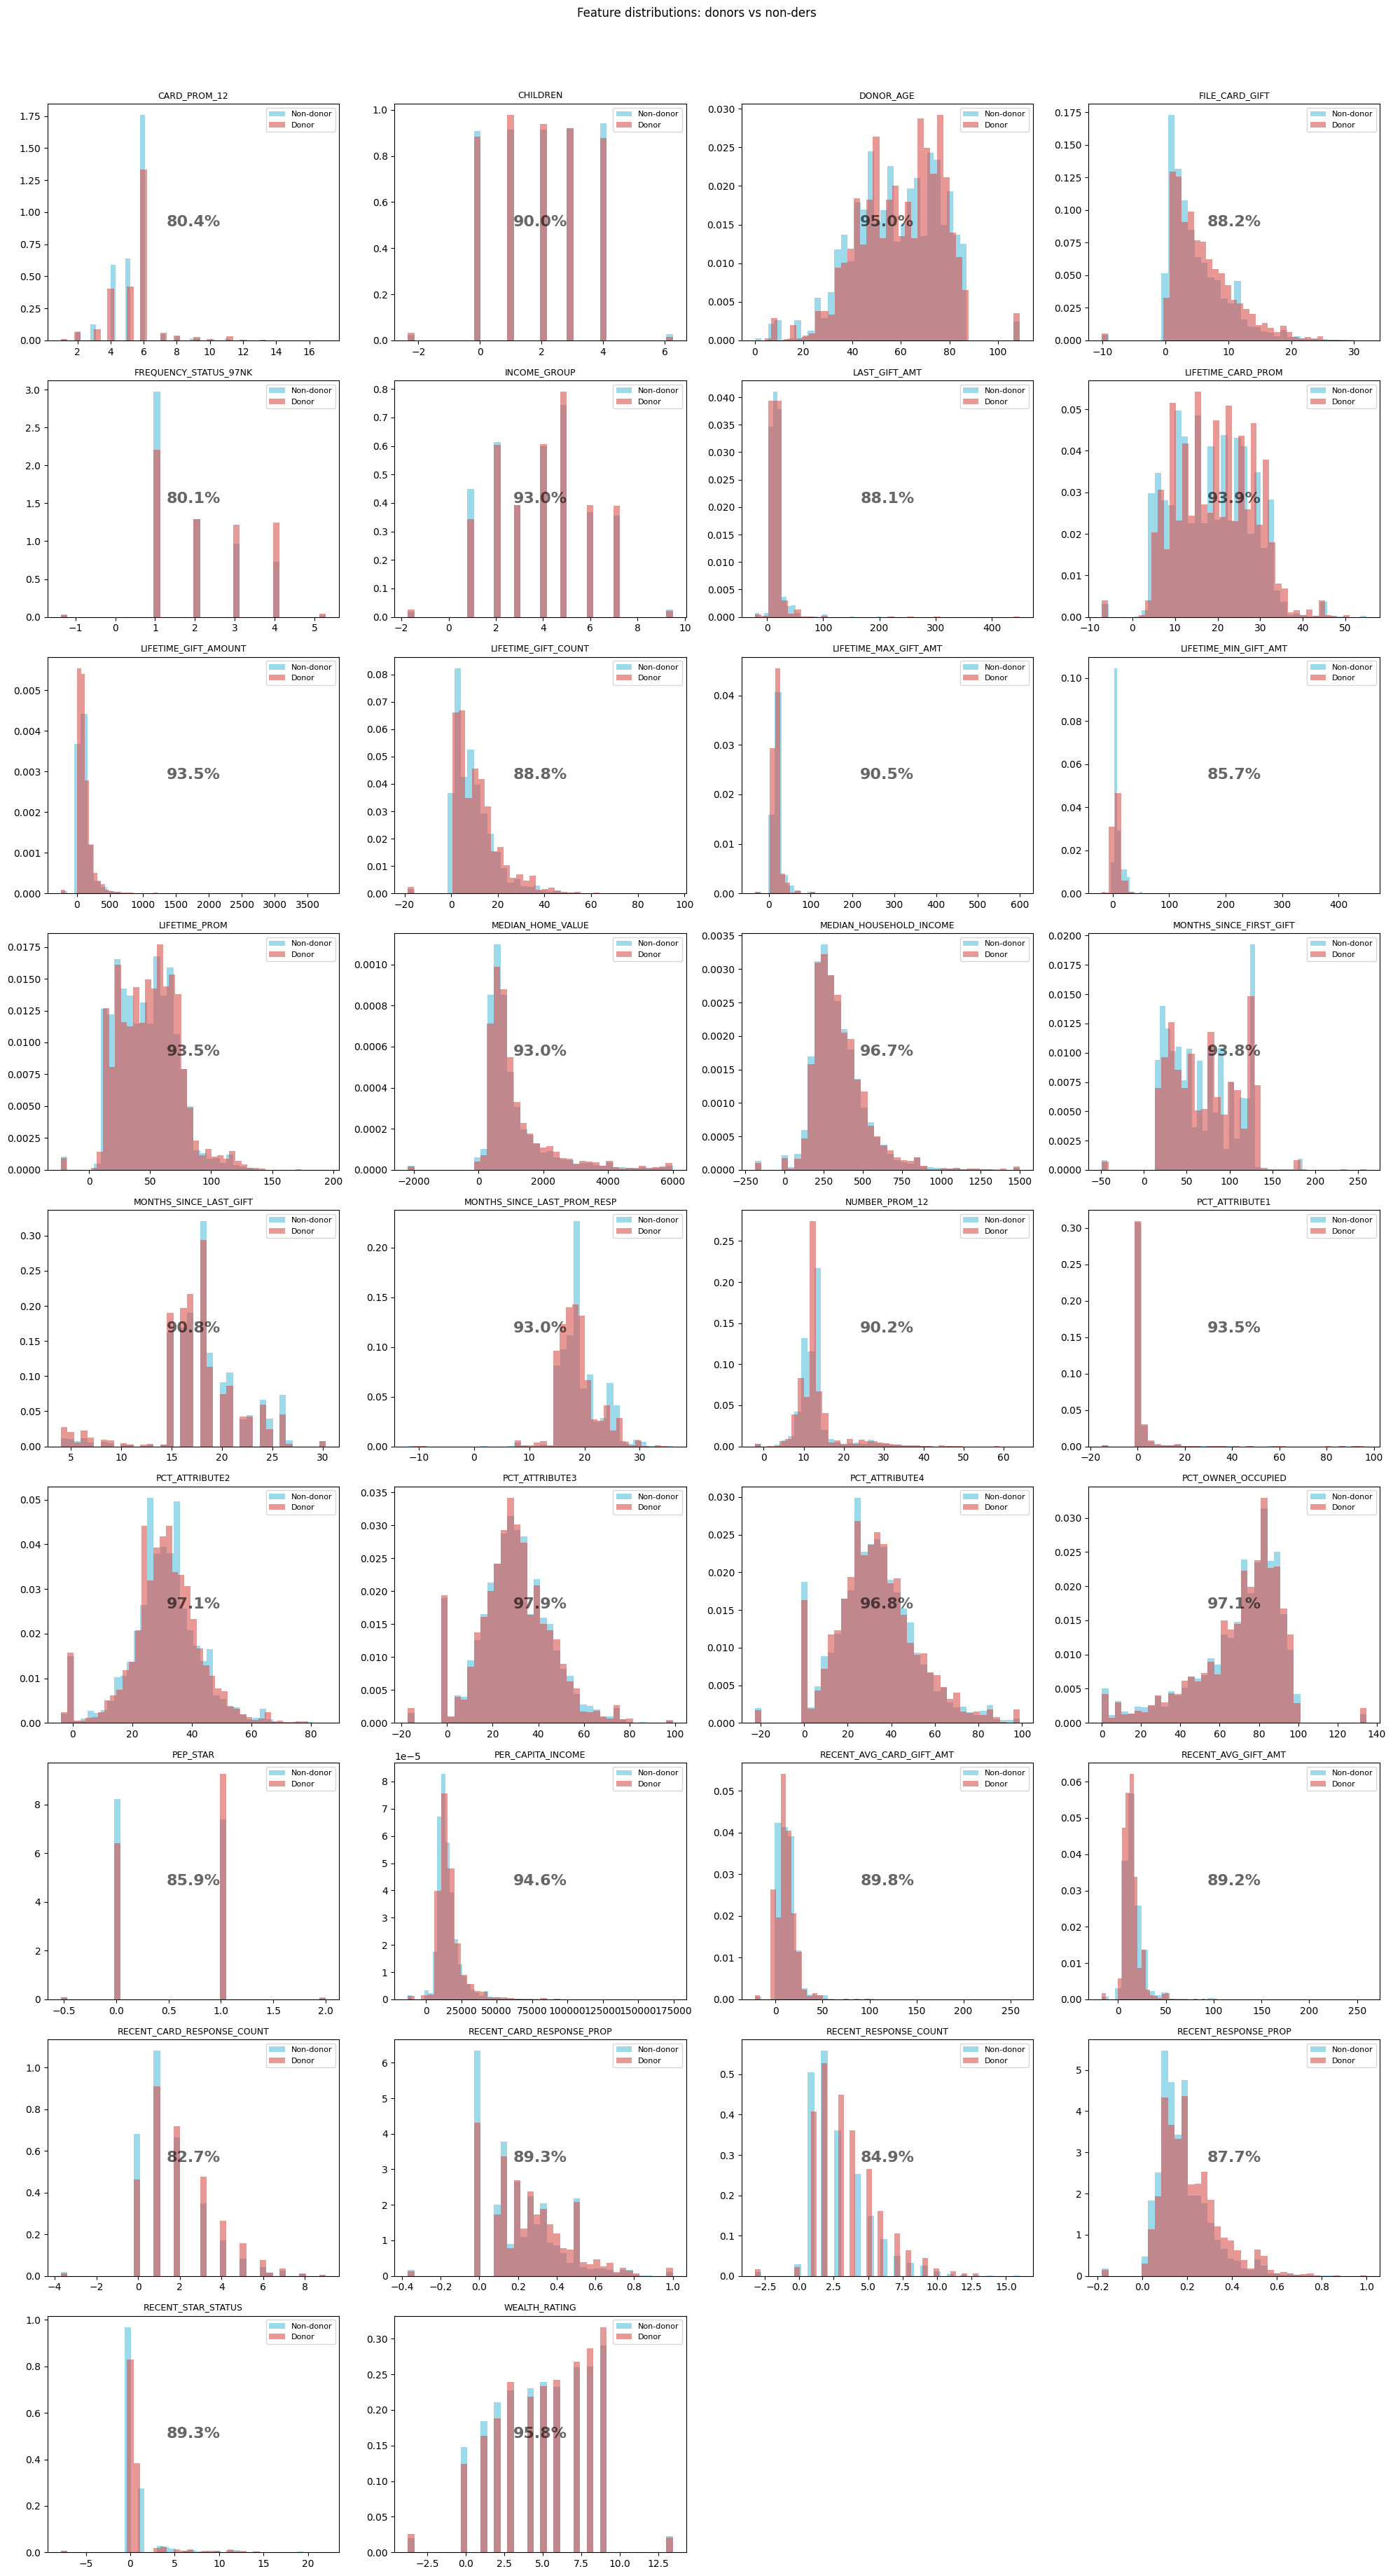

In [16]:
from scipy.stats import gaussian_kde
import numpy as np

num_cols = train_data.select_dtypes(include='number').columns.tolist()
num_cols = [col for col in num_cols if col != 'TARGET_B']

n_cols = 4
n_rows = -(-len(num_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    donors     = train_data.loc[train_data["TARGET_B"] == 1, col].dropna()
    non_donors = train_data.loc[train_data["TARGET_B"] == 0, col].dropna()

    ax.hist(non_donors, bins=40, alpha=0.6, label="Non-donor", color="#5bc0de", density=True)
    ax.hist(donors,     bins=40, alpha=0.6, label="Donor",     color="#d9534f", density=True)

    try:
        x = np.linspace(min(donors.min(), non_donors.min()),
                        max(donors.max(), non_donors.max()), 1000)
        kde_donors     = gaussian_kde(donors)(x)
        kde_non_donors = gaussian_kde(non_donors)(x)
        overlap = np.trapz(np.minimum(kde_donors, kde_non_donors), x)
        ax.set_title(col, fontsize=9)
        ax.text(0.5, 0.5, f"{overlap:.1%}", transform=ax.transAxes,
                ha="center", va="center", fontsize=16, fontweight="bold",
                color="black", alpha=0.6)
    except Exception:
        ax.set_title(col, fontsize=9)

    ax.legend(fontsize=8)

for ax in axes[len(num_cols):]:
    ax.set_visible(False)

plt.suptitle("Feature distributions: donors vs non-ders", y=1.02)
plt.tight_layout()
plt.show()

The overlap is calculated using KDE (Kernel Density Estimation) — it estimates the area where both distributions overlap. A high overlap (close to 100%) means the variable doesn't separate donors from non-donors well; a low overlap means it's a strong differentiator.

In [17]:
# Get a table with the distributions overlap percentages
from scipy.stats import gaussian_kde
import numpy as np

num_cols = train_data.select_dtypes(include='number').columns.tolist()
num_cols = [col for col in num_cols if col != 'TARGET_B']

overlap_results = []

for col in num_cols:
    donors     = train_data.loc[train_data["TARGET_B"] == 1, col].dropna()
    non_donors = train_data.loc[train_data["TARGET_B"] == 0, col].dropna()

    try:
        x = np.linspace(min(donors.min(), non_donors.min()),
                        max(donors.max(), non_donors.max()), 1000)
        kde_donors     = gaussian_kde(donors)(x)
        kde_non_donors = gaussian_kde(non_donors)(x)
        overlap = np.trapz(np.minimum(kde_donors, kde_non_donors), x)
    except Exception:
        overlap = None

    overlap_results.append({"Variable": col, "Overlap (%)": overlap})

overlap_df = pd.DataFrame(overlap_results)
overlap_df["Overlap (%)"] = (overlap_df["Overlap (%)"] * 100).round(2)
overlap_df = overlap_df.sort_values("Overlap (%)").reset_index(drop=True)

print(overlap_df.to_string(index=False))

/tmp/ipykernel_133833/1975529278.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  overlap = np.trapz(np.minimum(kde_donors, kde_non_donors), x)


                   Variable  Overlap (%)
      FREQUENCY_STATUS_97NK        80.13
               CARD_PROM_12        80.42
 RECENT_CARD_RESPONSE_COUNT        82.68
      RECENT_RESPONSE_COUNT        84.95
      LIFETIME_MIN_GIFT_AMT        85.66
                   PEP_STAR        85.91
       RECENT_RESPONSE_PROP        87.70
              LAST_GIFT_AMT        88.11
             FILE_CARD_GIFT        88.23
        LIFETIME_GIFT_COUNT        88.77
        RECENT_AVG_GIFT_AMT        89.16
  RECENT_CARD_RESPONSE_PROP        89.28
         RECENT_STAR_STATUS        89.30
   RECENT_AVG_CARD_GIFT_AMT        89.82
                   CHILDREN        90.04
             NUMBER_PROM_12        90.17
      LIFETIME_MAX_GIFT_AMT        90.52
     MONTHS_SINCE_LAST_GIFT        90.77
MONTHS_SINCE_LAST_PROM_RESP        92.97
               INCOME_GROUP        93.01
          MEDIAN_HOME_VALUE        93.04
             PCT_ATTRIBUTE1        93.50
              LIFETIME_PROM        93.51
       LIFETIME_

**Conclusion:** `FREQUENCY_STATUS_97K`, `CARD_PROM_12`, `RECENT_CARD_RESPONSE_COUNT`, `RECENT_RESPONSE_COUNT`, and `LIFETIME_MIN_GIFT_AMT` are the top 5 numeric variables that show the clearest separation between donors and non-donors.

<a class="anchor" id="3rd-bullet"></a>

# 3. Preprocess Data
Apply the minimum preprocessing needed before feature selection. All transformations are derived from the training data only to avoid data leakage.

The model assessment approach adopted in this project is **Holdout**: the labelled data is split once into a training set (80%) and a validation set (20%), using stratification to preserve the 75/25 class ratio in both partitions. This approach is appropriate for a dataset of this size (13,560 observations).

In [18]:
# Create a new df to store the clean data after fixes
data_clean = data.copy()
data_clean.head(5)

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B,DATA_TYPE
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,9.0,...,0.0,0.000,2.0,0.154,0.0,2,T,NaN,1.0,training
112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,6.0,...,1.0,0.250,1.0,0.100,0.0,3,R,NaN,1.0,training
166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,17.0,...,0.0,0.000,3.0,0.231,1.0,1,U,NaN,0.0,training
170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,28.0,...,2.0,0.286,2.0,0.111,0.0,1,U,NaN,0.0,training
44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,9.0,...,3.0,0.600,5.0,0.500,0.0,2,C,NaN,0.0,training


<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

<a class="anchor" id="3-1-bullet"></a>

## 3.1. Fix Outliers

</div>

**Step 11:** Fix the known quality issues identified during EDA. Each variable or group of variables is handled individually based on the nature of its problem.

### 3.1.1. `DONOR_AGE`

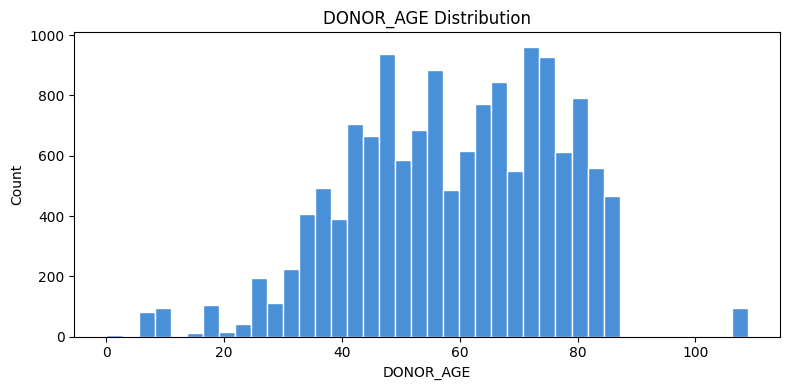

In [19]:
# Check distribution
plt.figure(figsize=(8, 4))
plt.hist(data_clean['DONOR_AGE'].dropna(), bins=40, color="#4a90d9", edgecolor='white')
plt.title("DONOR_AGE Distribution")
plt.xlabel("DONOR_AGE")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [20]:
# Identify the outliers (< 15 or >100)
below_15 = (data_clean['DONOR_AGE'] < 15).sum()
above_100 = (data_clean['DONOR_AGE'] > 100).sum()

print(f"Below 15 : {below_15}")
print(f"Above 100: {above_100}")
print(f"Total    : {below_15 + above_100}")

Below 15 : 186
Above 100: 95
Total    : 281


There are 281 entries that are outliers considering as outliers any ages below 15 and above 100. Since this is a very low percentage of records it is safe to assign them with the mean value of age.

In [21]:
# Fix outliers using mean for any ages below 15 and above 100 (excluding nulls)
mean_age = data_clean['DONOR_AGE'].mean()

data_clean['DONOR_AGE'] = data_clean['DONOR_AGE'].where(
    (data_clean['DONOR_AGE'].isna()) |
    ((data_clean['DONOR_AGE'] >= 15) & (data_clean['DONOR_AGE'] <= 100)), mean_age
)

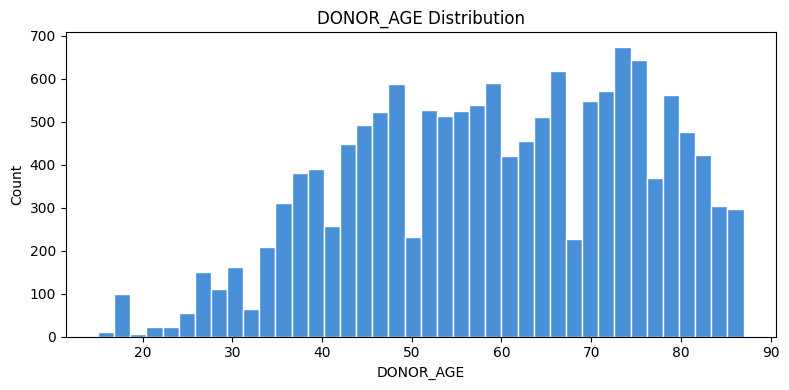

In [22]:
# Check distribution after fix
plt.figure(figsize=(8, 4))
plt.hist(data_clean['DONOR_AGE'].dropna(), bins=40, color="#4a90d9", edgecolor='white')
plt.title("DONOR_AGE Distribution")
plt.xlabel("DONOR_AGE")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 3.2.2. `CHILDREN`

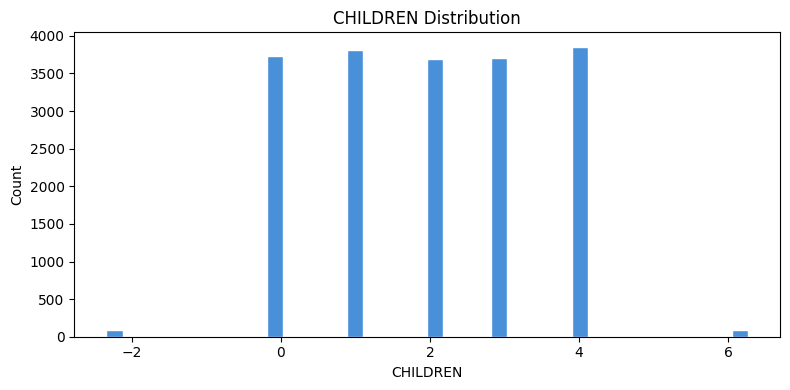

In [23]:
# Check distribution
plt.figure(figsize=(8, 4))
plt.hist(data_clean['CHILDREN'].dropna(), bins=40, color="#4a90d9", edgecolor='white')
plt.title("CHILDREN Distribution")
plt.xlabel("CHILDREN")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [24]:
# Identify outliers below 0 and above 4
negatives = data_clean[data_clean['CHILDREN'] < 0]['CHILDREN'].value_counts().sort_index()
above_4 = data_clean[data_clean['CHILDREN'] > 4]['CHILDREN'].value_counts().sort_index()

print("Negative values:")
print(negatives)
print("\nAbove 4:")
print(above_4)

Negative values:
CHILDREN
-2.341107    96
Name: count, dtype: int64

Above 4:
CHILDREN
6.264709    96
Name: count, dtype: int64


There are 96 donors with -2.341107 children and another 96 with exactly 6.2664709 children. Both cases seem to be a data collection/processing error, so we will update them using the median rounded to the integer.

In [25]:
# Fix outliers with media
median_children = round(data_clean['CHILDREN'].median())

data_clean['CHILDREN'] = data_clean['CHILDREN'].where(
    (data_clean['CHILDREN'].isna()) |
    ((data_clean['CHILDREN'] >= 0) & (data_clean['CHILDREN'] <= 5)), median_children
)

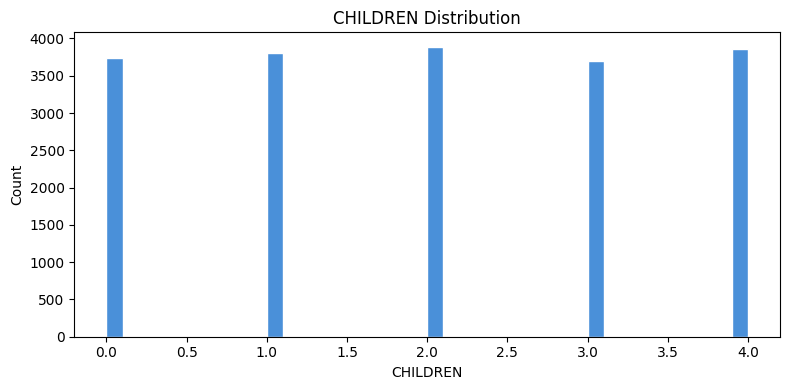

In [26]:
#Check distribution after fix
plt.figure(figsize=(8, 4))
plt.hist(data_clean['CHILDREN'].dropna(), bins=40, color="#4a90d9", edgecolor='white')
plt.title("CHILDREN Distribution")
plt.xlabel("CHILDREN")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 3.2.3. `INCOME_GROUP`

Kurtosis: -0.5830731702851941


<Axes: xlabel='INCOME_GROUP'>

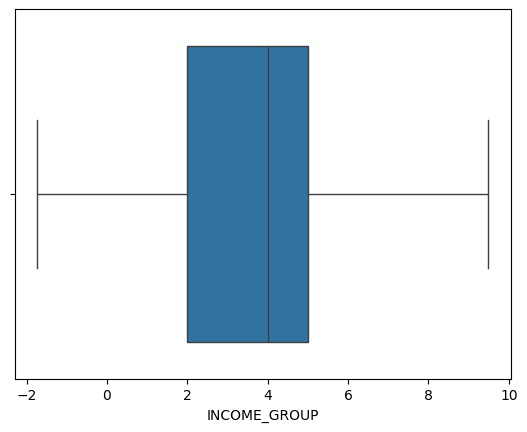

In [27]:
#Check Excess Kurtosis of column Income Group
print(f"Kurtosis: {data_clean['INCOME_GROUP'].kurt()}")

#Outliers
sns.boxplot(data_clean, x='INCOME_GROUP')

Excess Kurtosis level is inferior to zero. This tells us that there aren't many outliers in this data. Having checked the previous boxplot and knowing that the range of income group must be between 1 and 7, we can safely assume the outliers are values out of that range. In this case, checking the maximum and minimum values of Income group we can see that these are values that are negative and of type float. Let's fix them.

In [28]:
# Check for values out of range
data_clean['INCOME_GROUP'].value_counts(dropna=False)

,count
INCOME_GROUP,
NaN,4643
5.000000,3054
2.000000,2554
4.000000,2465
1.000000,1765
3.000000,1657
6.000000,1531
7.000000,1512
-1.728999,96


In [29]:
# Clip values to a range of 1 and 7
data_clean['INCOME_GROUP'].clip(lower=1, upper=7, axis=0, inplace=True)
data_clean['INCOME_GROUP'].value_counts(dropna=False)

/tmp/ipykernel_133833/2639938977.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_clean['INCOME_GROUP'].clip(lower=1, upper=7, axis=0, inplace=True)


,count
INCOME_GROUP,
NaN,4643
5.0,3054
2.0,2554
4.0,2465
1.0,1861
3.0,1657
7.0,1607
6.0,1531


### 3.2.4. Neighborhood Percentage Variables

All percentage variables should be between 0 and 100, so we applied clipping for any values outside that interval.

In [30]:
# Check outliers for values below 0 and above 1
pct_vars = ['PCT_OWNER_OCCUPIED', 'PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3', 'PCT_ATTRIBUTE4']

pct_results = []

for var in pct_vars:
    below_0 = (data_clean[var] < 0).sum()
    above_1 = (data_clean[var] > 100).sum()
    pct_results.append({
        'Variable': var,
        'Below 0': below_0,
        'Above 1': above_1,
        'Total': below_0 + above_1
    })

pct_df = pd.DataFrame(pct_results)
print(pct_df.to_string(index=False))

          Variable  Below 0  Above 1  Total
PCT_OWNER_OCCUPIED        0       96     96
    PCT_ATTRIBUTE1       96        0     96
    PCT_ATTRIBUTE2       96        0     96
    PCT_ATTRIBUTE3       96        0     96
    PCT_ATTRIBUTE4       96        0     96


We have a constant number of outliers (96) which seems to be a data processing issue, so we will apply the median to fix those.

In [31]:
# Fix the outliers using the median
for var in pct_vars:
    median_val = data_clean[var].median()
    data_clean[var] = data_clean[var].where(
        (data_clean[var] >= 0) & (data_clean[var] <= 100), median_val
    )

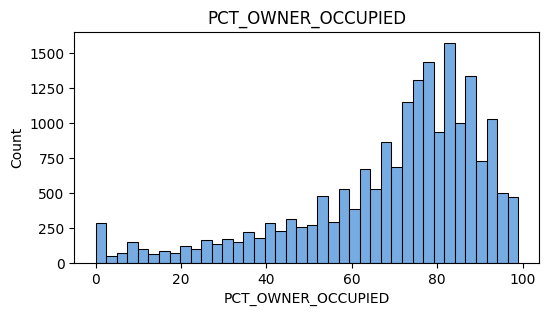

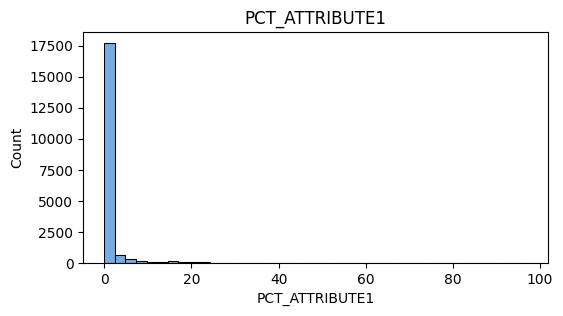

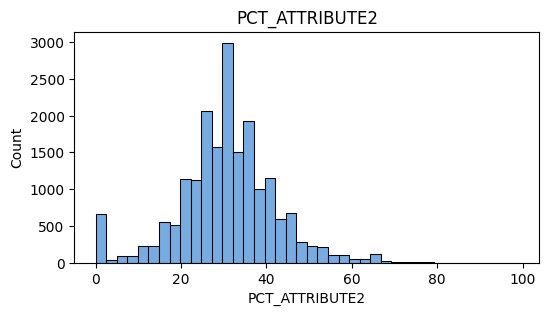

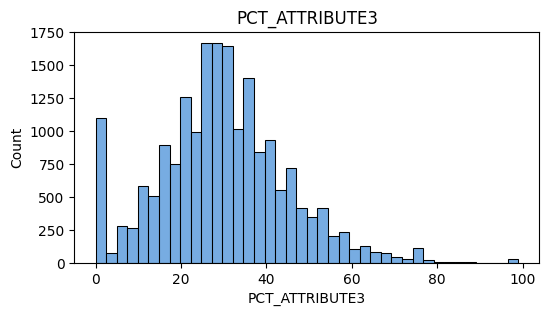

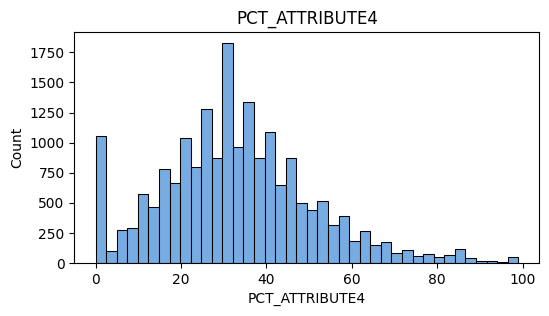

In [32]:
for var in pct_vars:
    plt.figure(figsize=(6, 3))
    sns.histplot(data_clean[var].dropna(), bins=40, color="#4a90d9")
    plt.title(var)
    plt.show()

### 3.2.5. Neighborhood Dollar Variables

For all variables related to dollar amounts with used the IQR methodology to define outliers and then applied clipping to fix them.

In [33]:
# Define outliers using the IQR method
neighborhood_vars = [
    'MEDIAN_HOME_VALUE',
    'MEDIAN_HOUSEHOLD_INCOME',
    'PER_CAPITA_INCOME',
]

outliers_results = []

for var in neighborhood_vars:
    Q1  = data_clean[var].quantile(0.25)
    Q3  = data_clean[var].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data_clean[(data_clean[var] < lower_bound) | (data_clean[var] > upper_bound)]

    outliers_results.append({
        "Variable": var,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": len(outliers)
    })

neighborhood_outliers_summary_table = pd.DataFrame(outliers_results)
print(neighborhood_outliers_summary_table.to_string(index=False))

               Variable      Q1      Q3    IQR  Lower Bound  Upper Bound  Outliers
      MEDIAN_HOME_VALUE   515.0  1232.0  717.0       -560.5       2307.5      1967
MEDIAN_HOUSEHOLD_INCOME   231.0   419.0  188.0        -51.0        701.0       757
      PER_CAPITA_INCOME 10832.0 18369.0 7537.0       -473.5      29674.5      1237


In [34]:
# Fix outliers using clipping
bounds = {}

for var in neighborhood_vars:
    Q1  = data_clean[var].quantile(0.25)
    Q3  = data_clean[var].quantile(0.75)
    IQR = Q3 - Q1

    bounds[var] = {
        'lower': Q1 - 1.5 * IQR,
        'upper': Q3 + 1.5 * IQR
    }

for var in neighborhood_vars:
    lower = bounds[var]['lower']
    upper = bounds[var]['upper']

    data_clean[var] = data_clean[var].clip(lower, upper)

In [35]:
# Verify remaining outliers after clipping
check_results = []

for _, row in neighborhood_outliers_summary_table.iterrows():
    var = row["Variable"]
    lower = row["Lower Bound"]
    upper = row["Upper Bound"]

    outliers = data_clean[(data_clean[var] < lower) | (data_clean[var] > upper)]

    check_results.append({
        "Variable": var,
        "Remaining Outliers": len(outliers)
    })

pd.DataFrame(check_results)

,Variable,Remaining Outliers
0,MEDIAN_HOME_VALUE,0
1,MEDIAN_HOUSEHOLD_INCOME,0
2,PER_CAPITA_INCOME,0


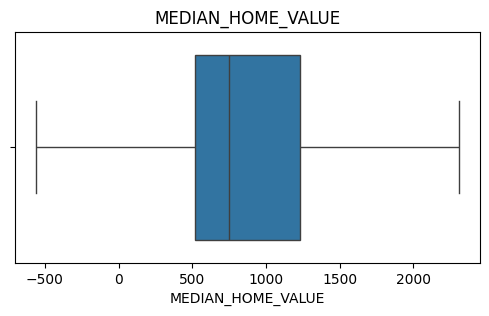

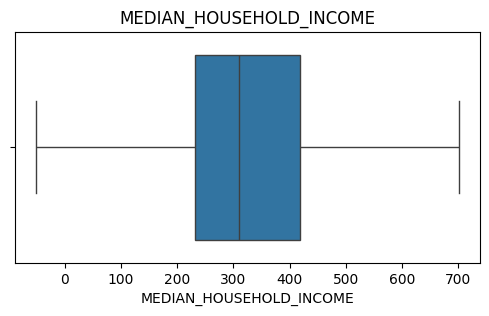

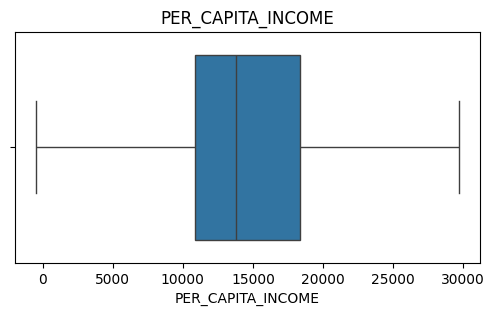

In [36]:
# Look at the visual impact using box plots
for var in neighborhood_vars:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=data_clean[var])
    plt.title(var)
    plt.show()

### 3.2.6. Campaign Counting Variables

For these variables we also applied the IQR methodology to flag and remove outliers with the help of clipping.

In [37]:
# Define outliers using the IQR method
cpgn_vars1 = ['LIFETIME_PROM','LIFETIME_CARD_PROM', 'RECENT_RESPONSE_COUNT', 'RECENT_CARD_RESPONSE_COUNT', 'NUMBER_PROM_12', 'CARD_PROM_12', 'MONTHS_SINCE_FIRST_GIFT', 'MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_LAST_PROM_RESP', 'LIFETIME_GIFT_COUNT','FREQUENCY_STATUS_97NK']

outliers_results = []

for var in cpgn_vars1:
    Q1  = data_clean[var].quantile(0.25)
    Q3  = data_clean[var].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data_clean[(data_clean[var] < lower_bound) | (data_clean[var] > upper_bound)]

    outliers_results.append({
        "Variable": var,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": len(outliers)
    })

outliers_summary_table = pd.DataFrame(outliers_results)
print(outliers_summary_table.to_string(index=False))

                   Variable   Q1    Q3  IQR  Lower Bound  Upper Bound  Outliers
              LIFETIME_PROM 28.0  64.0 36.0        -26.0        118.0       106
         LIFETIME_CARD_PROM 11.0  26.0 15.0        -11.5         48.5         9
      RECENT_RESPONSE_COUNT  2.0   4.0  2.0         -1.0          7.0       904
 RECENT_CARD_RESPONSE_COUNT  1.0   2.0  1.0         -0.5          3.5      2501
             NUMBER_PROM_12 11.0  13.0  2.0          8.0         16.0      2463
               CARD_PROM_12  5.0   6.0  1.0          3.5          7.5      1828
    MONTHS_SINCE_FIRST_GIFT 33.0 105.0 72.0        -75.0        213.0         2
     MONTHS_SINCE_LAST_GIFT 16.0  20.0  4.0         10.0         26.0      1092
MONTHS_SINCE_LAST_PROM_RESP 17.0  21.0  4.0         11.0         27.0       431
        LIFETIME_GIFT_COUNT  4.0  14.0 10.0        -11.0         29.0       850
      FREQUENCY_STATUS_97NK  1.0   3.0  2.0         -2.0          6.0         0


In [38]:
# Fix outliers using clipping
bounds = {}

for var in cpgn_vars1:
    Q1  = data_clean[var].quantile(0.25)
    Q3  = data_clean[var].quantile(0.75)
    IQR = Q3 - Q1

    bounds[var] = {
        'lower': Q1 - 1.5 * IQR,
        'upper': Q3 + 1.5 * IQR
    }

for var in cpgn_vars1:
    lower = bounds[var]['lower']
    upper = bounds[var]['upper']

    data_clean[var] = data_clean[var].clip(lower, upper)

In [39]:
# Verify remaining outliers after clipping
check_results = []

for _, row in outliers_summary_table.iterrows():
    var = row["Variable"]
    lower = row["Lower Bound"]
    upper = row["Upper Bound"]

    outliers = data_clean[(data_clean[var] < lower) | (data_clean[var] > upper)]

    check_results.append({
        "Variable": var,
        "Remaining Outliers": len(outliers)
    })

pd.DataFrame(check_results)

,Variable,Remaining Outliers
0,LIFETIME_PROM,0
1,LIFETIME_CARD_PROM,0
2,RECENT_RESPONSE_COUNT,0
3,RECENT_CARD_RESPONSE_COUNT,0
4,NUMBER_PROM_12,0
5,CARD_PROM_12,0
6,MONTHS_SINCE_FIRST_GIFT,0
7,MONTHS_SINCE_LAST_GIFT,0
8,MONTHS_SINCE_LAST_PROM_RESP,0
9,LIFETIME_GIFT_COUNT,0


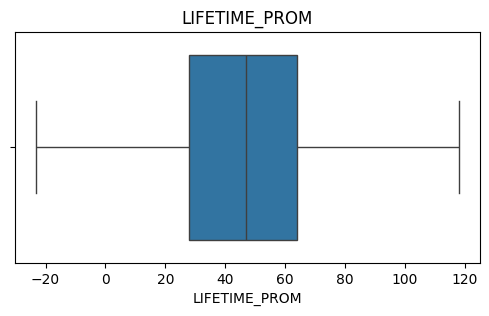

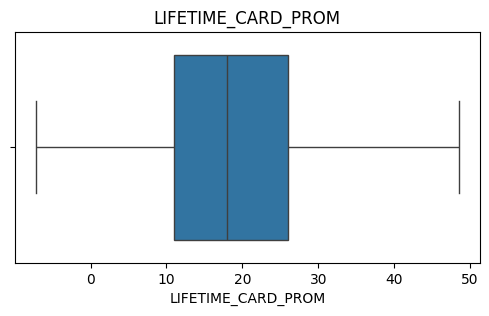

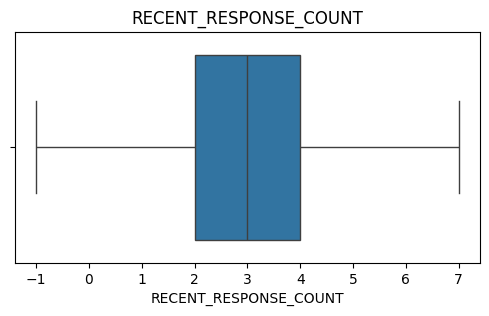

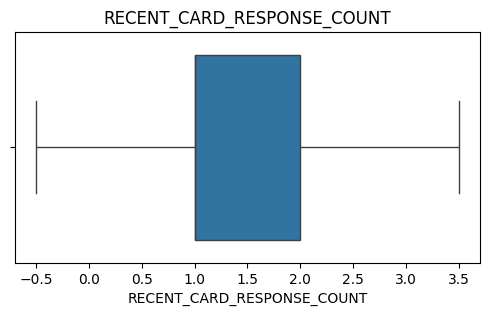

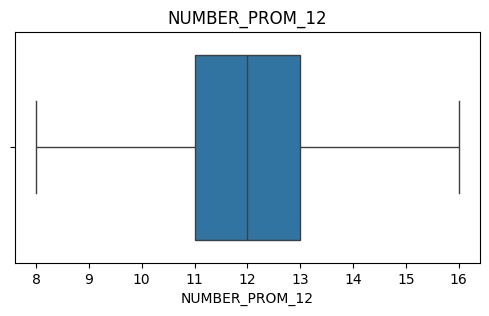

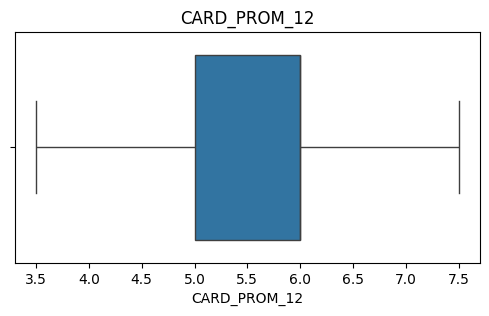

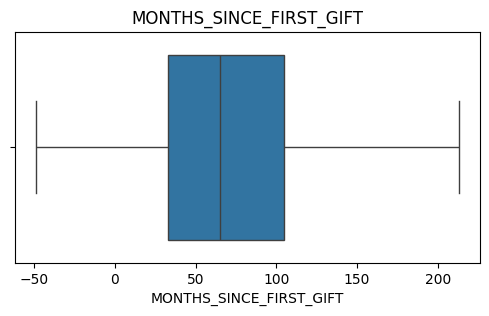

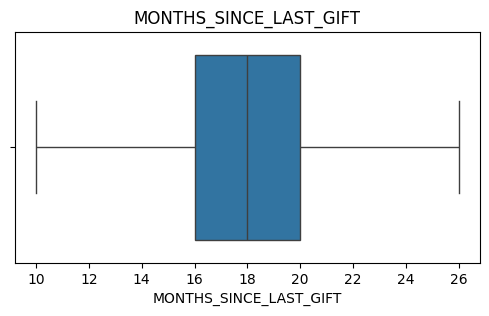

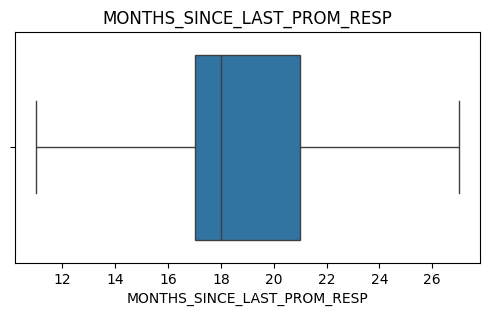

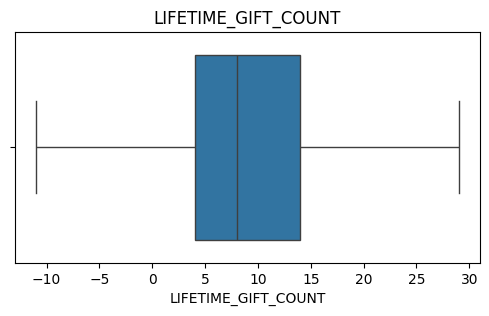

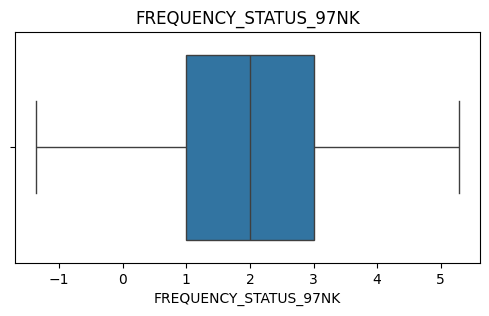

In [40]:
# Look at the visual impact using box plots
for var in cpgn_vars1:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=data_clean[var])
    plt.title(var)
    plt.show()

After removing the outilers we don't see any data points beyond the box plots' whiskers.

### 3.2.7. Campaign Proportion Variables

In [41]:
# Identigy outliers based on values below 0 and above 1
cpgn_vars2 = ['RECENT_RESPONSE_PROP', 'RECENT_CARD_RESPONSE_PROP']

prop_results = []

for var in cpgn_vars2:
    below_0 = (data_clean[var] < 0).sum()
    above_1 = (data_clean[var] > 1).sum()
    prop_results.append({
        'Variable': var,
        'Below 0': below_0,
        'Above 1': above_1,
        'Total': below_0 + above_1
    })

prop_df = pd.DataFrame(prop_results)
print(prop_df.to_string(index=False))

                 Variable  Below 0  Above 1  Total
     RECENT_RESPONSE_PROP       96        0     96
RECENT_CARD_RESPONSE_PROP       96        0     96


It seems again a data issue with exactly 96 values below, so we will apply the median to fix those.

In [42]:
# Fix outliers using the median
for var in cpgn_vars2:
    median_val = data_clean[var].median()
    data_clean[var] = data_clean[var].where(
        (data_clean[var] >= 0) & (data_clean[var] <= 1), median_val
    )

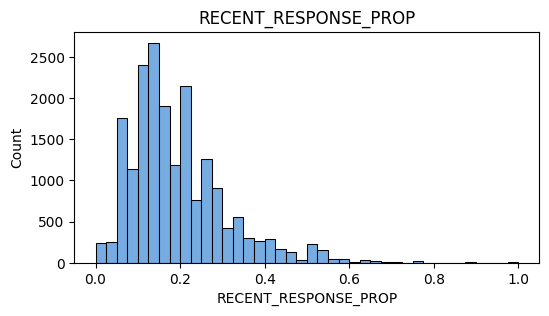

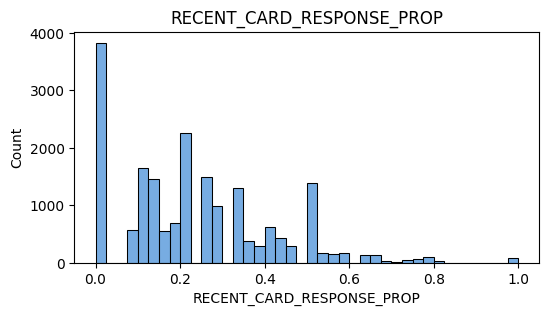

In [43]:
# Check distributions after fix
for var in cpgn_vars2:
    plt.figure(figsize=(6, 3))
    sns.histplot(data_clean[var].dropna(), bins=40, color="#4a90d9")
    plt.title(var)
    plt.show()

DONATION VARIABLES ($)

In [44]:
# Define outliers using the IQR method
donations_vars = [
    'RECENT_AVG_GIFT_AMT',
    'LAST_GIFT_AMT',
    'LIFETIME_GIFT_AMOUNT',
    'LIFETIME_MAX_GIFT_AMT',
    'LIFETIME_MIN_GIFT_AMT',
    'FILE_CARD_GIFT',
    'RECENT_AVG_CARD_GIFT_AMT'
]

outliers_results = []

for var in donations_vars:
    Q1  = data_clean[var].quantile(0.25)
    Q3  = data_clean[var].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data_clean[(data_clean[var] < lower_bound) | (data_clean[var] > upper_bound)]

    outliers_results.append({
        "Variable": var,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": len(outliers)
    })

donations_outliers_summary_table = pd.DataFrame(outliers_results)
print(donations_outliers_summary_table.to_string(index=False))

                Variable   Q1    Q3  IQR  Lower Bound  Upper Bound  Outliers
     RECENT_AVG_GIFT_AMT 10.0  20.0 10.0         -5.0         35.0       689
           LAST_GIFT_AMT 10.0  20.0 10.0         -5.0         35.0       794
    LIFETIME_GIFT_AMOUNT 41.0 132.0 91.0        -95.5        268.5      1155
   LIFETIME_MAX_GIFT_AMT 12.0  21.0  9.0         -1.5         34.5      1289
   LIFETIME_MIN_GIFT_AMT  3.0  10.0  7.0         -7.5         20.5      1064
          FILE_CARD_GIFT  2.0   8.0  6.0         -7.0         17.0       613
RECENT_AVG_CARD_GIFT_AMT  5.0  16.0 11.0        -11.5         32.5       606


In [45]:
# Fix outliers using clipping
bounds = {}

for var in donations_vars:
    Q1  = data_clean[var].quantile(0.25)
    Q3  = data_clean[var].quantile(0.75)
    IQR = Q3 - Q1

    bounds[var] = {
        'lower': Q1 - 1.5 * IQR,
        'upper': Q3 + 1.5 * IQR
    }

for var in donations_vars:
    lower = bounds[var]['lower']
    upper = bounds[var]['upper']

    data_clean[var] = data_clean[var].clip(lower, upper)

In [46]:
# Verify remaining outliers after clipping
check_results = []

for _, row in donations_outliers_summary_table.iterrows():
    var = row["Variable"]
    lower = row["Lower Bound"]
    upper = row["Upper Bound"]

    outliers = data_clean[(data_clean[var] < lower) | (data_clean[var] > upper)]

    check_results.append({
        "Variable": var,
        "Remaining Outliers": len(outliers)
    })

pd.DataFrame(check_results)

,Variable,Remaining Outliers
0,RECENT_AVG_GIFT_AMT,0
1,LAST_GIFT_AMT,0
2,LIFETIME_GIFT_AMOUNT,0
3,LIFETIME_MAX_GIFT_AMT,0
4,LIFETIME_MIN_GIFT_AMT,0
5,FILE_CARD_GIFT,0
6,RECENT_AVG_CARD_GIFT_AMT,0


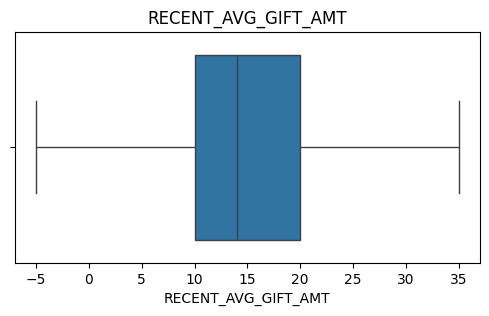

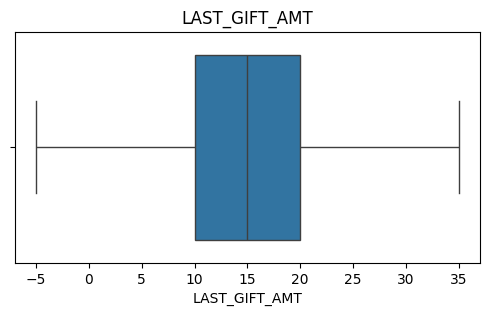

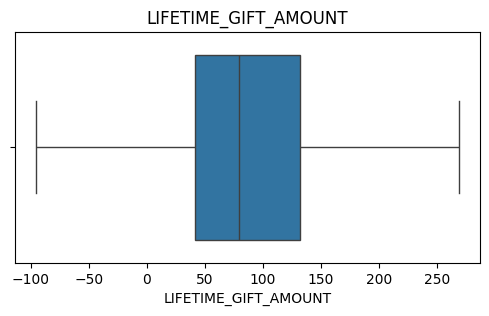

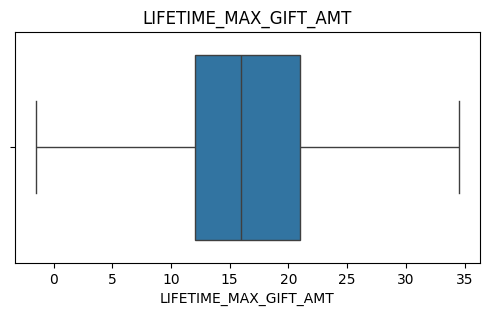

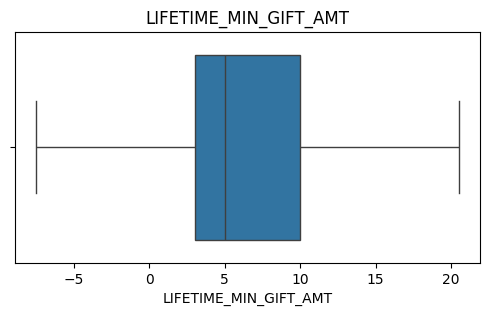

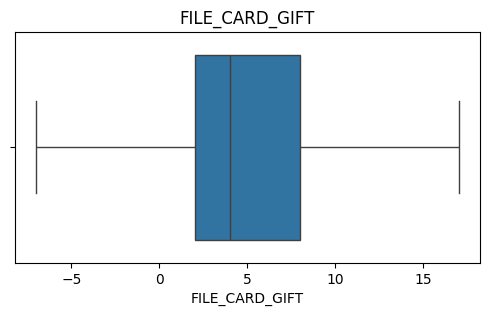

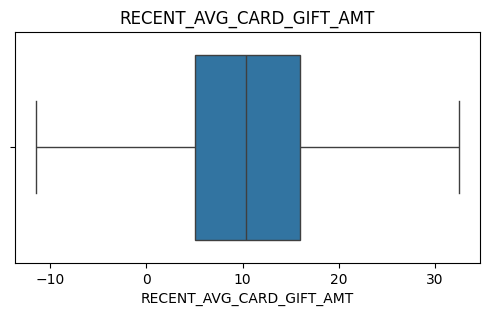

In [47]:
# Look at the visual impact using box plots
for var in donations_vars:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=data_clean[var])
    plt.title(var)
    plt.show()

<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

<a class="anchor" id="3-2-bullet"></a>

## 3.2. Missing Value Imputation

In [48]:
# Check missing values for all variables
missing = (data_clean.isnull().mean() * 100).sort_values(ascending=False)
missing_count = data_clean.isnull().sum().reindex(missing.index)

missing_df = pd.DataFrame({
    'Feature': missing.index,
    'Missing Count': missing_count.values,
    'Missing (%)': missing.values
})

missing_df = missing_df[missing_df['Missing (%)'] > 0].reset_index(drop=True)

print(missing_df.to_string(index=False))

                    Feature  Missing Count  Missing (%)
              WEALTH_RATING           8938    46.138757
                   TARGET_B           5812    30.002065
                  DONOR_AGE           5046    26.047904
               INCOME_GROUP           4643    23.967582
MONTHS_SINCE_LAST_PROM_RESP            621     3.205658
        RECENCY_STATUS_96NK            387     1.997729
                 HOME_OWNER            387     1.997729
               DONOR_GENDER            387     1.997729
                        SES            387     1.997729
                 URBANICITY            387     1.997729
                   CHILDREN            386     1.992567
        RECENT_AVG_GIFT_AMT            386     1.992567
       LIFETIME_GIFT_AMOUNT            386     1.992567
      RECENT_RESPONSE_COUNT            385     1.987405
   RECENT_AVG_CARD_GIFT_AMT            385     1.987405
              LAST_GIFT_AMT            385     1.987405
               CARD_PROM_12            385     1

### 3.2.1. `INCOME_GROUP`

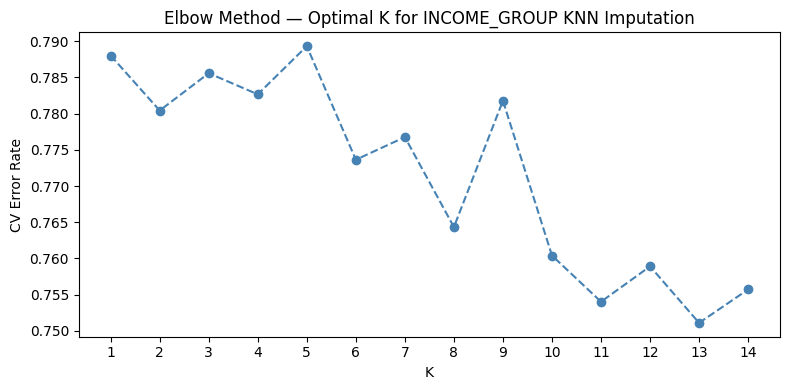

In [49]:
# Use KNN based on SES, Wealth Rating and Home Owner

from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score as cvs

# ── INCOME_GROUP: find optimal K via elbow method ────────────────────────
knn_prep = data_clean[["INCOME_GROUP", "SES", "WEALTH_RATING", "HOME_OWNER"]].copy()
knn_prep["HOME_OWNER"] = knn_prep["HOME_OWNER"].map({"H": 1, "U": 0}).fillna(0)
knn_prep["SES"] = pd.to_numeric(knn_prep["SES"], errors="coerce")

df_known = knn_prep.dropna(subset=["INCOME_GROUP"])
X_knn = df_known[["SES", "WEALTH_RATING", "HOME_OWNER"]].fillna(
    df_known[["SES", "WEALTH_RATING", "HOME_OWNER"]].median()
)
y_knn = df_known["INCOME_GROUP"].astype(int)

k_range     = range(1, 15)
error_rates = []
for k in k_range:
    scores = cvs(
        KNeighborsClassifier(n_neighbors=k, weights="distance"),
        X_knn, y_knn, cv=5, scoring="accuracy"
    )
    error_rates.append(1 - scores.mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), error_rates, marker="o", linestyle="--", color="steelblue")
ax.set_xlabel("K"); ax.set_ylabel("CV Error Rate")
ax.set_title("Elbow Method — Optimal K for INCOME_GROUP KNN Imputation")
ax.set_xticks(list(k_range))
plt.tight_layout(); plt.show()

In [50]:
# Apply KNN imputation
optimal_k = 10
print(f"N-Neighbors: {optimal_k}")

knn_cols  = ["INCOME_GROUP", "SES", "WEALTH_RATING", "HOME_OWNER"]
knn_input = knn_prep[knn_cols].copy()

pipeline_knn = Pipeline([
    ("scaler",  StandardScaler()),
    ("imputer", KNNImputer(n_neighbors=optimal_k, weights="distance"))
])

imputed_knn  = pipeline_knn.fit_transform(knn_input)
imputed_orig = pipeline_knn.named_steps["scaler"].inverse_transform(imputed_knn)

data_clean["INCOME_GROUP"] = (
    pd.Series(np.round(imputed_orig[:, 0]).clip(1, 7).astype(int), index=data_clean.index)
)

print(f"INCOME_GROUP — KNN imputation complete (K={optimal_k}), missing remaining: {data_clean['INCOME_GROUP'].isna().sum()}")

N-Neighbors: 10
INCOME_GROUP — KNN imputation complete (K=10), missing remaining: 0


3.2.2. `DONOR_AGE`

In [51]:
# Fix DONOR_AGE using random resamplings
known_ages   = data_clean["DONOR_AGE"].dropna()
missing_mask = data_clean["DONOR_AGE"].isna()
random_ages  = known_ages.sample(n=missing_mask.sum(), replace=True, random_state=42).values
data_clean.loc[missing_mask, "DONOR_AGE"] = random_ages
data_clean["DONOR_AGE"] = data_clean["DONOR_AGE"].astype(int)
print(f"DONOR_AGE — {missing_mask.sum()} missing values filled by random resampling")

DONOR_AGE — 5046 missing values filled by random resampling


### 3.2.3. Non-binary Numeric Variables

In [52]:
# Replace missing values with median for non-binary variables
data_clean.fillna({
    'LIFETIME_PROM': data_clean['LIFETIME_PROM'].median(),
    'LIFETIME_CARD_PROM': data_clean['LIFETIME_CARD_PROM'].median(),
    'RECENT_RESPONSE_COUNT': data_clean['RECENT_RESPONSE_COUNT'].median(),
    'RECENT_CARD_RESPONSE_COUNT': data_clean['RECENT_CARD_RESPONSE_COUNT'].median(),
    'NUMBER_PROM_12': data_clean['NUMBER_PROM_12'].median(),
    'CARD_PROM_12': data_clean['CARD_PROM_12'].median(),
    'RECENT_RESPONSE_PROP': data_clean['RECENT_RESPONSE_PROP'].median(),
    'RECENT_CARD_RESPONSE_PROP': data_clean['RECENT_CARD_RESPONSE_PROP'].median(),
    'LIFETIME_GIFT_COUNT': data_clean['LIFETIME_GIFT_COUNT'].median(),
    'FREQUENCY_STATUS_97NK': data_clean['FREQUENCY_STATUS_97NK'].median(),
    'MEDIAN_HOME_VALUE': data_clean['MEDIAN_HOME_VALUE'].median(),
    'MEDIAN_HOUSEHOLD_INCOME': data_clean['MEDIAN_HOUSEHOLD_INCOME'].median(),
    'PCT_OWNER_OCCUPIED': data_clean['PCT_OWNER_OCCUPIED'].median(),
    'PER_CAPITA_INCOME': data_clean['PER_CAPITA_INCOME'].median(),
    'PCT_ATTRIBUTE1': data_clean['PCT_ATTRIBUTE1'].median(),
    'PCT_ATTRIBUTE2': data_clean['PCT_ATTRIBUTE2'].median(),
    'PCT_ATTRIBUTE3': data_clean['PCT_ATTRIBUTE3'].median(),
    'PCT_ATTRIBUTE4': data_clean['PCT_ATTRIBUTE4'].median(),
    'RECENT_AVG_GIFT_AMT': data_clean['RECENT_AVG_GIFT_AMT'].median(),
    'LAST_GIFT_AMT': data_clean['LAST_GIFT_AMT'].median(),
    'LIFETIME_GIFT_AMOUNT': data_clean['LIFETIME_GIFT_AMOUNT'].median(),
    'LIFETIME_MAX_GIFT_AMT': data_clean['LIFETIME_MAX_GIFT_AMT'].median(),
    'LIFETIME_MIN_GIFT_AMT': data_clean['LIFETIME_MIN_GIFT_AMT'].median(),
    'FILE_CARD_GIFT': data_clean['FILE_CARD_GIFT'].median(),
    'RECENT_AVG_CARD_GIFT_AMT': data_clean['RECENT_AVG_CARD_GIFT_AMT'].median(),
    'CHILDREN': data_clean['CHILDREN'].median(),
}, inplace=True)

### 3.2.4. Month Variables

In [53]:
# Fixing for Months variables
data_clean['MONTHS_SINCE_LAST_GIFT'].fillna(data_clean['MONTHS_SINCE_LAST_PROM_RESP'], inplace=True)
data_clean['MONTHS_SINCE_LAST_GIFT'].fillna(data_clean['MONTHS_SINCE_LAST_GIFT'].median(), inplace=True)
data_clean['MONTHS_SINCE_LAST_PROM_RESP'].fillna(data_clean['MONTHS_SINCE_LAST_GIFT'], inplace=True)
data_clean['MONTHS_SINCE_FIRST_GIFT'].fillna(data_clean['MONTHS_SINCE_LAST_GIFT'], inplace=True)

/tmp/ipykernel_133833/4054452437.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_clean['MONTHS_SINCE_LAST_GIFT'].fillna(data_clean['MONTHS_SINCE_LAST_PROM_RESP'], inplace=True)


### 3.2.5. `RECENT_STAR_STATUS` and `PEP_STAR`

In [54]:
# Fixing for RECENT_STAR_STATUS and PEP_STAR
data_clean['RECENT_STAR_STATUS'].fillna(0, inplace=True)
data_clean['PEP_STAR'].fillna(data_clean['RECENT_STAR_STATUS'], inplace=True)

/tmp/ipykernel_133833/1024171047.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_clean['RECENT_STAR_STATUS'].fillna(0, inplace=True)


### 3.2.6. Caterogical Variables

In [55]:
# Check again values for Categorical Variables
for col in ['URBANICITY', 'SES', 'DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK']:
    print(f"{col}:")
    print(data_clean[col].value_counts(dropna=False))
    print()

URBANICITY:
URBANICITY
S      4394
C      3938
R      3934
T      3868
U      2407
?       444
NaN     387
Name: count, dtype: int64

SES:
SES
2      9099
1      5807
3      3266
?       439
NaN     387
4       374
Name: count, dtype: int64

DONOR_GENDER:
DONOR_GENDER
F      10209
M       7778
U        998
NaN      387
Name: count, dtype: int64

HOME_OWNER:
HOME_OWNER
H      10394
U       8591
NaN      387
Name: count, dtype: int64

RECENCY_STATUS_96NK:
RECENCY_STATUS_96NK
A      11691
S       4121
F       1493
N       1166
E        421
NaN      387
L         93
Name: count, dtype: int64



In [56]:
# Change '?' to null for URBANICITY and SES
data_clean['URBANICITY'] = data_clean['URBANICITY'].replace('?', np.nan)
data_clean['SES'] = data_clean['SES'].replace('?', np.nan)

In [57]:
# Fixing nulls for Categorical Variables using the Mode
data_clean['DONOR_GENDER'].fillna(data_clean['DONOR_GENDER'].mode()[0], inplace=True)
data_clean['HOME_OWNER'].fillna(data_clean['HOME_OWNER'].mode()[0], inplace=True)
data_clean['RECENCY_STATUS_96NK'].fillna(data_clean['RECENCY_STATUS_96NK'].mode()[0], inplace=True)
data_clean['SES'].fillna(data_clean['SES'].mode()[0], inplace=True)
data_clean['URBANICITY'].fillna(data_clean['URBANICITY'].mode()[0], inplace=True)

/tmp/ipykernel_133833/3681693422.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_clean['DONOR_GENDER'].fillna(data_clean['DONOR_GENDER'].mode()[0], inplace=True)


### 3.2.7. Final Checks

In [58]:
# Checking missing values after fixes
missing = (data_clean.isnull().mean() * 100).sort_values(ascending=False)
missing_count = data_clean.isnull().sum().reindex(missing.index)

missing_df = pd.DataFrame({
    'Feature': missing.index,
    'Missing Count': missing_count.values,
    'Missing (%)': missing.values
})

print(missing_df.to_string(index=False))

                    Feature  Missing Count  Missing (%)
              WEALTH_RATING           8938    46.138757
                   TARGET_B           5812    30.002065
                  DONOR_AGE              0     0.000000
                   CHILDREN              0     0.000000
             FILE_CARD_GIFT              0     0.000000
      FREQUENCY_STATUS_97NK              0     0.000000
                 HOME_OWNER              0     0.000000
               DONOR_GENDER              0     0.000000
               CARD_PROM_12              0     0.000000
              LAST_GIFT_AMT              0     0.000000
               INCOME_GROUP              0     0.000000
         LIFETIME_CARD_PROM              0     0.000000
       LIFETIME_GIFT_AMOUNT              0     0.000000
      LIFETIME_MIN_GIFT_AMT              0     0.000000
              LIFETIME_PROM              0     0.000000
        LIFETIME_GIFT_COUNT              0     0.000000
      LIFETIME_MAX_GIFT_AMT              0     0

In [59]:
# Drop WEALTH_RATING for having almost 50% of missing values
data_clean.drop(columns=['WEALTH_RATING'], inplace=True)

**Conclusion:** All missing values resolved using variable-specific strategies. `DONOR_AGE` was filled by random resampling from the observed distribution, preserving its shape rather than creating an artificial median spike. `INCOME_GROUP` used KNN imputation guided by correlated sociodemographic neighbours. The months and star status variables were aligned using their domain relationship before median fallback. The `WEALTH_RATING` was removed for having a very large proportion of missing values (almost 50%).

## 3.3. Misclassifications & Incoherencies

### 3.3.1. Negative Values

In [60]:
#Identity negative values
negative_counts = (data_clean.select_dtypes(include='number') < 0).sum()
negative_df = negative_counts[negative_counts > 0].reset_index()
negative_df.columns = ['Feature', 'Negative Count']

print(negative_df.to_string(index=False))

                   Feature  Negative Count
            FILE_CARD_GIFT              96
     FREQUENCY_STATUS_97NK              96
             LAST_GIFT_AMT              96
        LIFETIME_CARD_PROM              96
      LIFETIME_GIFT_AMOUNT              96
       LIFETIME_GIFT_COUNT              96
     LIFETIME_MAX_GIFT_AMT              96
     LIFETIME_MIN_GIFT_AMT              96
             LIFETIME_PROM              96
         MEDIAN_HOME_VALUE              96
   MEDIAN_HOUSEHOLD_INCOME              96
   MONTHS_SINCE_FIRST_GIFT              96
                  PEP_STAR             100
         PER_CAPITA_INCOME              96
  RECENT_AVG_CARD_GIFT_AMT              96
       RECENT_AVG_GIFT_AMT              96
RECENT_CARD_RESPONSE_COUNT              96
     RECENT_RESPONSE_COUNT              96
        RECENT_STAR_STATUS              96


The same data inconsistency with exactly 96 negative values across multiple values. We replaced them with the median with the exception of `PEP-STAR` and `RECENT_STAR_STATUS` that are binary variables so its negative values were changed to 0 for now.

In [61]:
# Variables to replace negatives with median
replace_with_median = [
    'FILE_CARD_GIFT', 'FREQUENCY_STATUS_97NK', 'LAST_GIFT_AMT', 'LIFETIME_CARD_PROM',
    'LIFETIME_GIFT_AMOUNT', 'LIFETIME_GIFT_COUNT', 'LIFETIME_MAX_GIFT_AMT',
    'LIFETIME_MIN_GIFT_AMT', 'LIFETIME_PROM', 'MONTHS_SINCE_FIRST_GIFT',
    'PCT_ATTRIBUTE3', 'PCT_ATTRIBUTE4', 'RECENT_AVG_CARD_GIFT_AMT',
    'RECENT_AVG_GIFT_AMT', 'RECENT_CARD_RESPONSE_COUNT', 'RECENT_CARD_RESPONSE_PROP',
    'RECENT_RESPONSE_COUNT', 'RECENT_RESPONSE_PROP',
    'MEDIAN_HOME_VALUE', 'MEDIAN_HOUSEHOLD_INCOME', 'PER_CAPITA_INCOME'
]

# Variables to replace negatives with 0
replace_with_zero = ['PEP_STAR', 'RECENT_STAR_STATUS']

# Replace negatives with median
for var in replace_with_median:
    median_val = data_clean[var].median()
    data_clean[var] = data_clean[var].where(data_clean[var] >= 0, median_val)

# Replace negatives with 0
for var in replace_with_zero:
    data_clean[var] = data_clean[var].where(data_clean[var] >= 0, 0)

In [62]:
# Check negative values after fix
negative_counts = (data_clean.select_dtypes(include='number') < 0).sum()
negative_df = negative_counts[negative_counts > 0].reset_index()
negative_df.columns = ['Feature', 'Negative Count']

print(negative_df.to_string(index=False))

Empty DataFrame
Columns: [Feature, Negative Count]
Index: []


### 3.3.2. Number of Promotions and Donations

We built some logic to keep consistency in the number of promotions (card vs. all) and donations over different timeframes.

In [63]:
# Checking for inconsistencies in number of promotions
card12_over_promos12 = (data_clean['CARD_PROM_12'] > data_clean['NUMBER_PROM_12']).sum()
card12_over_lifetimecard = (data_clean['CARD_PROM_12'] > data_clean['LIFETIME_CARD_PROM']).sum()
lifetimecard_over_lifetime = (data_clean['LIFETIME_CARD_PROM'] > data_clean['LIFETIME_PROM']).sum()
promos12_over_lifetime = (data_clean['NUMBER_PROM_12'] > data_clean['LIFETIME_PROM']).sum()
lifetimegifts_over_lifetimepromos = (data_clean['LIFETIME_GIFT_COUNT'] > data_clean['LIFETIME_PROM']).sum()
lastgift_over_lastresp = (data_clean['MONTHS_SINCE_LAST_GIFT'] > data_clean['MONTHS_SINCE_LAST_PROM_RESP']).sum()
lastgift_over_firstgift = (data_clean['MONTHS_SINCE_LAST_GIFT'] > data_clean['MONTHS_SINCE_FIRST_GIFT']).sum()
frequency_over_lifetime = (data_clean['FREQUENCY_STATUS_97NK'] > data_clean['LIFETIME_PROM']).sum()

metrics_map = {
    "card12_over_promos12": card12_over_promos12,
    "card12_over_lifetimecard": card12_over_lifetimecard,
    "lifetimecard_over_lifetime": lifetimecard_over_lifetime,
    "promos12_over_lifetime": promos12_over_lifetime,
    "lifetimegifts_over_lifetimepromos": lifetimegifts_over_lifetimepromos,
    "lastgift_over_lastresp": lastgift_over_lastresp,
    "lastgift_over_firstgift": lastgift_over_firstgift,
    "frequency_over_lifetime": frequency_over_lifetime
}

for k, v in metrics_map.items():
    print(f"{k:35s}: {v}")

card12_over_promos12               : 0
card12_over_lifetimecard           : 83
lifetimecard_over_lifetime         : 85
promos12_over_lifetime             : 37
lifetimegifts_over_lifetimepromos  : 30
lastgift_over_lastresp             : 190
lastgift_over_firstgift            : 11
frequency_over_lifetime            : 0


In [64]:
# Fix inconsistencies using a loop function to make sure all variables get aligned
max_iterations = 5

for i in range(max_iterations):
    # Fixing lifetime card promotions
    cond1 = data_clean['CARD_PROM_12'] > data_clean['LIFETIME_CARD_PROM']
    data_clean.loc[cond1, 'LIFETIME_CARD_PROM'] = data_clean.loc[cond1, 'CARD_PROM_12']

    # Fixing lifetime promotions
    cond2 = (data_clean['LIFETIME_CARD_PROM'] > data_clean['LIFETIME_PROM']) | \
            (data_clean['NUMBER_PROM_12'] > data_clean['LIFETIME_PROM']) | \
            (data_clean['LIFETIME_GIFT_COUNT'] > data_clean['LIFETIME_PROM'])
    cols_cond2 = ['LIFETIME_CARD_PROM', 'NUMBER_PROM_12', 'LIFETIME_GIFT_COUNT']
    data_clean.loc[cond2, 'LIFETIME_PROM'] = data_clean.loc[cond2, cols_cond2].max(axis=1)

    # Fixing months since last gift
    cond3 = data_clean['MONTHS_SINCE_LAST_GIFT'] > data_clean['MONTHS_SINCE_LAST_PROM_RESP']
    data_clean.loc[cond3, 'MONTHS_SINCE_LAST_GIFT'] = data_clean.loc[cond3, 'MONTHS_SINCE_LAST_PROM_RESP']

    # Fixing months since first gift
    cond4 = data_clean['MONTHS_SINCE_LAST_GIFT'] > data_clean['MONTHS_SINCE_FIRST_GIFT']
    data_clean.loc[cond4, 'MONTHS_SINCE_FIRST_GIFT'] = data_clean.loc[cond4, 'MONTHS_SINCE_LAST_GIFT']

    # Check if any inconsistencies remain
    remaining = cond1.sum() + cond2.sum() + cond3.sum() + cond4.sum()
    print(f"Iteration {i+1}: {remaining} inconsistencies remaining")
    if remaining == 0:
        break

Iteration 1: 423 inconsistencies remaining
Iteration 2: 0 inconsistencies remaining


In [65]:
print("URBANICITY:")
print(data_clean['URBANICITY'].value_counts(dropna=False))
print("\nSES:")
print(data_clean['SES'].value_counts(dropna=False))

URBANICITY:
URBANICITY
S    5225
C    3938
R    3934
T    3868
U    2407
Name: count, dtype: int64

SES:
SES
2    9925
1    5807
3    3266
4     374
Name: count, dtype: int64


### 3.3.3. Binary Variables

In [66]:
# Possible Range is binary (0 or 1)
outliers_star_status = ((data_clean['PEP_STAR'] != 0) & (data_clean['PEP_STAR'] != 1)).sum()
outliers1_star_status = ((data_clean['PEP_STAR'] < 0) | (data_clean['PEP_STAR'] > 1)).sum()
outliers2_star_status = ((data_clean['PEP_STAR'] > 0) & (data_clean['PEP_STAR'] < 1)).sum()

outliers_recent_status = ((data_clean['RECENT_STAR_STATUS'] != 0) & (data_clean['RECENT_STAR_STATUS'] != 1)).sum()
outliers1_recent_status = ((data_clean['RECENT_STAR_STATUS'] < 0) | (data_clean['RECENT_STAR_STATUS'] > 1)).sum()
outliers2_recent_status = ((data_clean['RECENT_STAR_STATUS'] > 0) & (data_clean['RECENT_STAR_STATUS'] < 1)).sum()

print(f"'PEP_STAR': \n Total inconsistencies: {outliers_star_status} of which {outliers1_star_status} are out of the range [0,1], and {outliers2_star_status} are decimal between 0 and 1")
print("\n")
print(f"'RECENT_STAR_STATUS': \n Total inconsistencies: {outliers_recent_status} of which {outliers1_recent_status} are out of the range [0,1], and {outliers2_recent_status} are decimal between 0 and 1")
print("\n")

data_clean[['PEP_STAR', 'RECENT_STAR_STATUS']].describe()

'PEP_STAR': 
 Total inconsistencies: 135 of which 135 are out of the range [0,1], and 0 are decimal between 0 and 1


'RECENT_STAR_STATUS': 
 Total inconsistencies: 1894 of which 1894 are out of the range [0,1], and 0 are decimal between 0 and 1




,PEP_STAR,RECENT_STAR_STATUS
count,19372.000000,19372.000000
mean,0.517879,0.950960
std,0.627599,2.578011
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,0.000000
75%,1.000000,1.000000
max,18.000000,22.000000


In [67]:
# Fix using clipping and results
data_clean['PEP_STAR'] = data_clean['PEP_STAR'].clip(0, 1)
data_clean['RECENT_STAR_STATUS'] = data_clean['RECENT_STAR_STATUS'].clip(0, 1)

outliers_star_status = ((data_clean['PEP_STAR'] != 0) & (data_clean['PEP_STAR'] != 1)).sum()
outliers_recent_status = ((data_clean['RECENT_STAR_STATUS'] != 0) & (data_clean['RECENT_STAR_STATUS'] != 1)).sum()

print(f"'PEP_STAR': \n Total inconsistencies: {outliers_star_status}")
print("\n")
print(f"'RECENT_STAR_STATUS': \n Total inconsistencies: {outliers_recent_status}")
print("\n")

data_clean[['PEP_STAR', 'RECENT_STAR_STATUS']].describe()

'PEP_STAR': 
 Total inconsistencies: 0


'RECENT_STAR_STATUS': 
 Total inconsistencies: 0




,PEP_STAR,RECENT_STAR_STATUS
count,19372.000000,19372.000000
mean,0.500310,0.313339
std,0.500013,0.463863
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,0.000000
75%,1.000000,1.000000
max,1.000000,1.000000


In [68]:
# Flag inconsistencies where PEP_STAR is 1 and RECENT_STAR_STATUS is 0
PEPvsRECENT = (data_clean['RECENT_STAR_STATUS'] > data_clean['PEP_STAR']).sum()

print(f"Total inconsistencies: {PEPvsRECENT}")

Total inconsistencies: 78


In [69]:
# Fix and verify results
cond3 = data_clean['RECENT_STAR_STATUS'] > data_clean['PEP_STAR']
data_clean.loc[cond3, 'PEP_STAR'] = data_clean.loc[cond3, 'RECENT_STAR_STATUS']

PEPvsRECENT = (data_clean['RECENT_STAR_STATUS'] > data_clean['PEP_STAR']).sum()

print(f"Total inconsistencies: {PEPvsRECENT}")

data_clean[['PEP_STAR', 'RECENT_STAR_STATUS']].value_counts()

Total inconsistencies: 0


PEP_STAR  RECENT_STAR_STATUS
0.0       0.0                   9602
1.0       1.0                   6070
          0.0                   3700
Name: count, dtype: int64

### 3.3.4. Data Types

In [70]:
# Check data types
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19372 entries, 61745 to 65406
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CARD_PROM_12                 19372 non-null  float64
 1   CHILDREN                     19372 non-null  float64
 2   DONOR_AGE                    19372 non-null  int64  
 3   DONOR_GENDER                 19372 non-null  object 
 4   FILE_CARD_GIFT               19372 non-null  float64
 5   FREQUENCY_STATUS_97NK        19372 non-null  float64
 6   HOME_OWNER                   19372 non-null  object 
 7   INCOME_GROUP                 19372 non-null  int64  
 8   LAST_GIFT_AMT                19372 non-null  float64
 9   LIFETIME_CARD_PROM           19372 non-null  float64
 10  LIFETIME_GIFT_AMOUNT         19372 non-null  float64
 11  LIFETIME_GIFT_COUNT          19372 non-null  float64
 12  LIFETIME_MAX_GIFT_AMT        19372 non-null  float64
 13  LIFETIME_MIN_GIFT

In [71]:
# Update data types
int_cols = [
    'CHILDREN', 'FREQUENCY_STATUS_97NK', 'NUMBER_PROM_12', 'PEP_STAR',
    'RECENT_CARD_RESPONSE_COUNT', 'RECENT_RESPONSE_COUNT', 'RECENT_STAR_STATUS'
]

# Convert to int (excluding TARGET_B since it has nulls)
data_clean[int_cols] = data_clean[int_cols].astype(int)

# TARGET_B has nulls so use Int64 (nullable integer)
data_clean['TARGET_B'] = data_clean['TARGET_B'].astype('Int64')

In [72]:
# Double check results
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19372 entries, 61745 to 65406
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CARD_PROM_12                 19372 non-null  float64
 1   CHILDREN                     19372 non-null  int64  
 2   DONOR_AGE                    19372 non-null  int64  
 3   DONOR_GENDER                 19372 non-null  object 
 4   FILE_CARD_GIFT               19372 non-null  float64
 5   FREQUENCY_STATUS_97NK        19372 non-null  int64  
 6   HOME_OWNER                   19372 non-null  object 
 7   INCOME_GROUP                 19372 non-null  int64  
 8   LAST_GIFT_AMT                19372 non-null  float64
 9   LIFETIME_CARD_PROM           19372 non-null  float64
 10  LIFETIME_GIFT_AMOUNT         19372 non-null  float64
 11  LIFETIME_GIFT_COUNT          19372 non-null  float64
 12  LIFETIME_MAX_GIFT_AMT        19372 non-null  float64
 13  LIFETIME_MIN_GIFT

In [73]:
#FINAL RESULTS FOR NUMERIC VARIABLES
data_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
CARD_PROM_12,19372.0,5.381943,0.980845,3.5,5.0,6.0,6.0,7.5
CHILDREN,19372.0,2.007175,1.397986,0.0,1.0,2.0,3.0,4.0
DONOR_AGE,19372.0,59.344002,16.035512,15.0,47.0,59.0,73.0,87.0
FILE_CARD_GIFT,19372.0,5.211336,4.347015,0.0,2.0,4.0,8.0,17.0
FREQUENCY_STATUS_97NK,19372.0,2.000361,1.104031,1.0,1.0,2.0,3.0,5.0
INCOME_GROUP,19372.0,3.652695,1.779424,1.0,2.0,4.0,5.0,7.0
LAST_GIFT_AMT,19372.0,15.874391,7.473081,0.0,10.0,15.0,20.0,35.0
LIFETIME_CARD_PROM,19372.0,18.782075,8.610106,3.5,12.0,18.0,26.0,48.5
LIFETIME_GIFT_AMOUNT,19372.0,97.328069,69.452207,15.0,43.0,79.0,131.0,268.5
LIFETIME_GIFT_COUNT,19372.0,9.698431,7.563563,1.0,4.0,8.0,14.0,29.0


In [74]:
data_clean

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,TARGET_B,DATA_TYPE
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
61745,4.0,2,33,M,0.0,1,H,5,20.0,9.0,...,17.50,0,0.000,2,0.154,0,2,T,1,training
112703,3.5,2,55,F,1.0,1,U,1,15.0,6.0,...,15.00,1,0.250,1,0.100,0,3,R,1,training
166437,4.0,0,74,F,7.0,3,H,4,10.0,17.0,...,10.67,0,0.000,3,0.231,1,1,U,0,training
170621,4.0,4,61,M,13.0,1,H,6,11.0,28.0,...,10.00,2,0.286,2,0.111,0,1,U,0,training
44428,6.0,3,75,M,3.0,4,H,3,7.0,9.0,...,5.40,3,0.600,5,0.500,0,2,C,0,training
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54438,6.0,0,27,M,5.0,1,U,4,17.0,18.0,...,16.00,2,0.200,2,0.095,1,2,R,<NA>,testing
122194,6.0,1,42,M,3.0,2,H,7,20.0,11.0,...,14.00,3,0.429,3,0.214,0,1,C,<NA>,testing
106603,3.5,0,81,F,8.0,3,H,2,10.0,21.0,...,8.40,1,0.400,5,0.238,0,3,T,<NA>,testing


<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

<a class="anchor" id="3-3-bullet"></a>

## 3.4. Holdout Split — 80% Train / 20% Validation

</div>

**Step 13:** Split the data into training and validation sets using an 80/20 holdout.

`stratify=y_full` ensures that the 75/25 class ratio is preserved in both partitions, which is critical given the class imbalance identified in Section 2.4.

In [75]:
#Split Pre Processed DataFrame into training and validation dataframes
X_full = data_clean[data_clean['DATA_TYPE'] == 'training'].drop(columns=['DATA_TYPE', 'TARGET_B'])
y_full = data_clean["TARGET_B"][data_clean['DATA_TYPE'] == 'training']

#Get testing dataframe cleaned
test_cleaned = data_clean[data_clean['DATA_TYPE'] == 'testing'].drop(columns=['DATA_TYPE', 'TARGET_B'])

In [76]:
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_full
)

print(f"Training set   : {X_train.shape[0]:,} rows  |  Donation rate: {y_train.mean():.2%}")
print(f"Validation set : {X_val.shape[0]:,} rows  |  Donation rate: {y_val.mean():.2%}")
print(f"\nClass ratio preserved — train: {(1-y_train.mean()):.2%} / {y_train.mean():.2%}  |  val: {(1-y_val.mean()):.2%} / {y_val.mean():.2%}")

Training set   : 10,848 rows  |  Donation rate: 25.00%
Validation set : 2,712 rows  |  Donation rate: 25.00%

Class ratio preserved — train: 75.00% / 25.00%  |  val: 75.00% / 25.00%


**Conclusion:** The stratified split confirms that the 75/25 class ratio is preserved in both partitions. All subsequent feature-selection steps operate exclusively on `X_train` and `y_train` to ensure that validation data has no influence on the feature set chosen.

<a class="anchor" id="4th-bullet"></a>

# 4. Feature Selection
Apply a structured sequence of filter methods to remove uninformative and redundant predictors before modelling.

The methods are applied in the following order, consistent with the approach used in class:
1. **Chi-Square** — identify categorical predictors with no association to the target.
2. **Variance** — identify numerical predictors that are near-constant.
3. **Spearman Correlation** — identify redundant continuous predictors.

All methods are applied only to the training partition.

<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

<a class="anchor" id="4-1-bullet"></a>

## 4.1. Categorical Variables — Chi-Square (Filter Method)

Use chi-square to test whether each categorical predictor has a statistically significant association with `TARGET_B`.

</div>

**Step 14:** Create a function named `apply_chisquare` that evaluates one categorical predictor against the target using `chi2_contingency`.

In [77]:
def apply_chisquare(X_col, y, var, alpha=0.05):
    df_observed = pd.crosstab(y, X_col)
    chi2, p, dof, expected = stats.chi2_contingency(df_observed.values)
    if p < alpha:
        result = f"{var} is IMPORTANT for prediction  (p={p:.4f})"
    else:
        result = f"{var} is NOT an important predictor — discard  (p={p:.4f})"
    print(result)
    return p < alpha

**Step 15:** Apply `apply_chisquare` to every categorical predictor using only the training data.

In [78]:
print("Chi-Square feature screening on training data\n")
print("=" * 60)

cat_features = ["DONOR_GENDER", "HOME_OWNER", "RECENCY_STATUS_96NK", "SES", "URBANICITY"]
chi2_results = {}

for var in cat_features:
    chi2_results[var] = apply_chisquare(X_train[var], y_train, var)

Chi-Square feature screening on training data

DONOR_GENDER is NOT an important predictor — discard  (p=0.6499)
HOME_OWNER is NOT an important predictor — discard  (p=0.0800)
RECENCY_STATUS_96NK is IMPORTANT for prediction  (p=0.0000)
SES is IMPORTANT for prediction  (p=0.0000)
URBANICITY is NOT an important predictor — discard  (p=0.2292)


**Conclusion — Chi-Square summary:**

| Feature | Result | Decision |
| --- | --- | --- |
| DONOR_GENDER | — | — |
| HOME_OWNER | — | — |
| RECENCY_STATUS_96NK | — | — |
| SES | — | — |
| URBANICITY | — | — |

*(Fill in after running — mark IMPORTANT / NOT IMPORTANT and KEEP / REMOVE based on the p-values above.)*

**Step 16:** Drop any categorical features that were not retained by chi-square across all runs.

In [79]:
# Update this list after reviewing the chi-square output above
# Example: if DONOR_GENDER and HOME_OWNER are not significant, drop them
cat_to_drop = [var for var, keep in chi2_results.items() if not keep]
print(f"Categorical features to drop: {cat_to_drop}")

if cat_to_drop:
    X_train = X_train.drop(columns=cat_to_drop)
    X_val   = X_val.drop(columns=cat_to_drop)
    print(f"X_train shape after chi-square drop: {X_train.shape}")

Categorical features to drop: ['DONOR_GENDER', 'HOME_OWNER', 'URBANICITY']
X_train shape after chi-square drop: (10848, 35)


<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

<a class="anchor" id="4-2-bullet"></a>

## 4.2. Numerical Variables — Variance (Filter Method)

Use variance to identify numerical predictors that are near-constant across the training data and therefore carry no predictive information.

</div>

**Step 17:** Create a function named `apply_variance` that prints the variance of a single numerical predictor.

In [80]:
def apply_variance(X_train_col, var_name):
    variance = X_train_col.var()
    print(f"{var_name:45s}: {variance:.4f}")
    return variance

**Step 18:** Apply `apply_variance` to all numerical predictors in the training set and flag any with variance at or near zero.

In [81]:
print("Variance check on numerical features (training data)\n")
print("=" * 60)

num_features = X_train.select_dtypes(include=np.number).columns.tolist()
variance_results = {}

for var in num_features:
    variance_results[var] = apply_variance(X_train[var], var)

# Flag features with very low variance
VARIANCE_THRESHOLD = 0.001
low_var = [v for v, val in variance_results.items() if val <= VARIANCE_THRESHOLD]
print(f"\nFeatures with variance ≤ {VARIANCE_THRESHOLD}: {low_var}")

Variance check on numerical features (training data)

CARD_PROM_12                                 : 0.9593
CHILDREN                                     : 1.9311
DONOR_AGE                                    : 257.0042
FILE_CARD_GIFT                               : 18.7511
FREQUENCY_STATUS_97NK                        : 1.2102
INCOME_GROUP                                 : 3.1576
LAST_GIFT_AMT                                : 56.3676
LIFETIME_CARD_PROM                           : 74.2544
LIFETIME_GIFT_AMOUNT                         : 4820.5118
LIFETIME_GIFT_COUNT                          : 58.1198
LIFETIME_MAX_GIFT_AMT                        : 51.2578
LIFETIME_MIN_GIFT_AMT                        : 30.3882
LIFETIME_PROM                                : 520.9791
MEDIAN_HOME_VALUE                            : 380714.5086
MEDIAN_HOUSEHOLD_INCOME                      : 20547.6094
MONTHS_SINCE_FIRST_GIFT                      : 1487.6346
MONTHS_SINCE_LAST_GIFT                       : 12.8561
MO

**Step 19:** Drop any near-constant numerical features identified by the variance check.

In [82]:
if low_var:
    X_train = X_train.drop(columns=low_var)
    X_val   = X_val.drop(columns=low_var)
    print(f"Dropped: {low_var}")
    print(f"X_train shape after variance drop: {X_train.shape}")
else:
    print("No features dropped — all numerical features have sufficient variance.")

No features dropped — all numerical features have sufficient variance.


<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

<a class="anchor" id="4-3-bullet"></a>

## 4.3. Numerical Variables — Spearman Correlation (Filter Method)

Use Spearman correlation to detect pairs of continuous predictors that are redundant — carrying effectively the same information. When a pair exceeds the |0.8| threshold, use domain knowledge or a baseline decision tree to decide which one to retain.

</div>

**Step 20:** Create a function `cor_heatmap` that plots a Spearman correlation heatmap for the numerical training features.

In [83]:
def cor_heatmap(cor, title="Spearman correlation matrix"):
    fig, ax = plt.subplots(figsize=(14, 11))
    mask = np.triu(np.ones_like(cor, dtype=bool))
    sns.heatmap(
        cor, mask=mask, annot=True, fmt=".1f",
        cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        linewidths=0.3, ax=ax, annot_kws={"size": 7}
    )
    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()

**Step 21:** Compute the Spearman correlation matrix on the numerical training features and plot it.

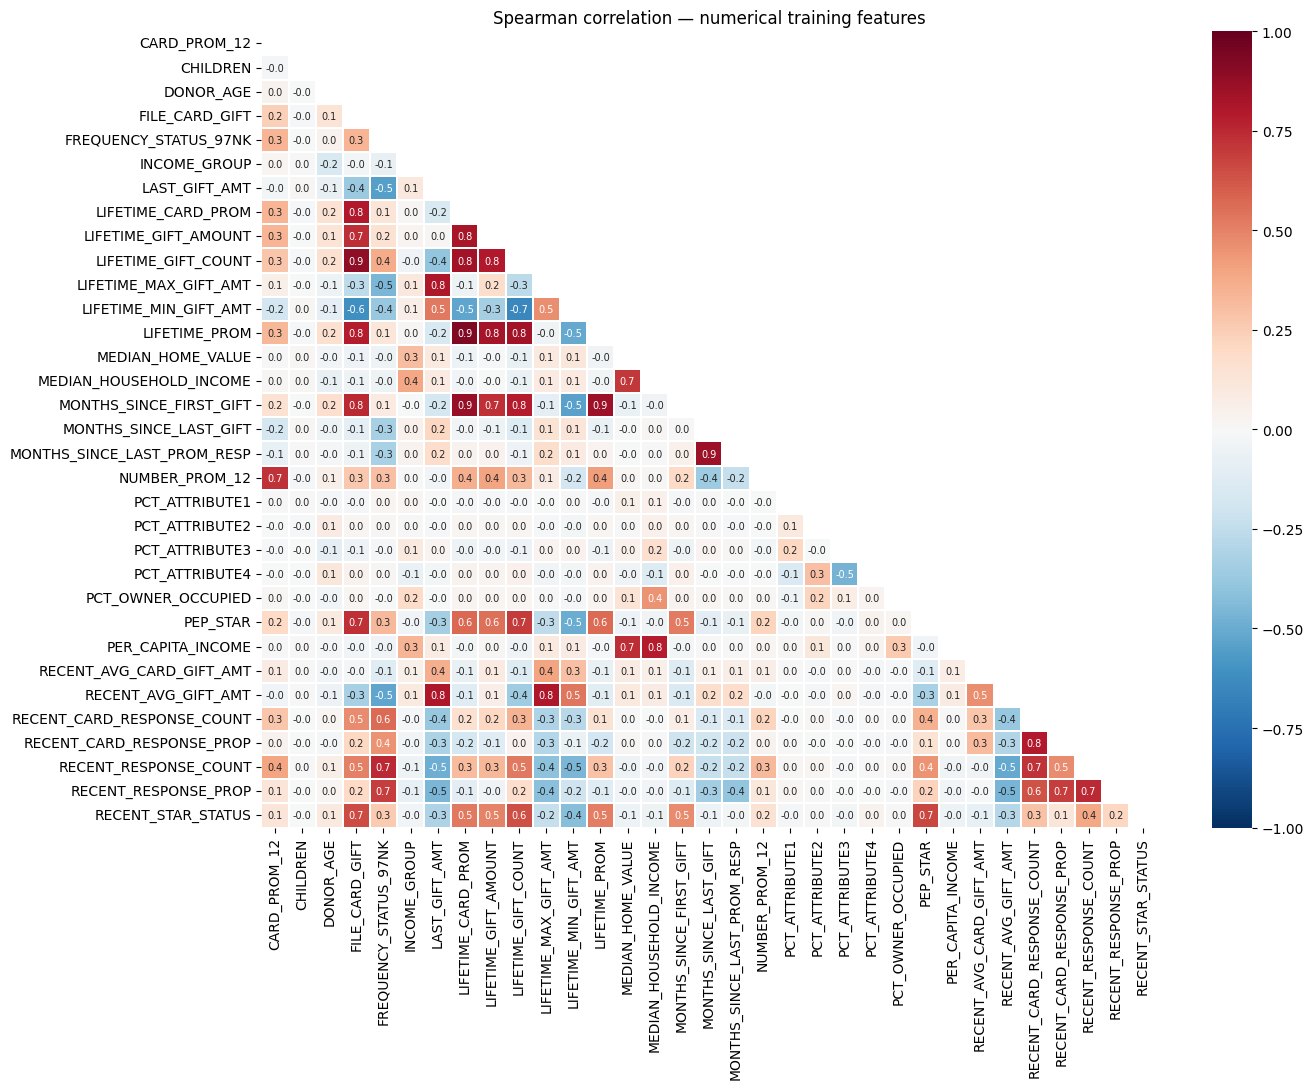

In [84]:
num_only = X_train.select_dtypes(include=np.number).copy()
spearman_matrix = num_only.corr(method="spearman")
cor_heatmap(spearman_matrix, "Spearman correlation — numerical training features")

**Step 22:** Extract all pairs with absolute Spearman correlation above |0.8| and print them for review.

In [85]:
CORR_THRESHOLD = 0.8
high_corr_pairs = []

cols = spearman_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        val = abs(spearman_matrix.iloc[i, j])
        if val >= CORR_THRESHOLD:
            high_corr_pairs.append((cols[i], cols[j], round(spearman_matrix.iloc[i, j], 3)))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Feature A", "Feature B", "Spearman r"])
high_corr_df = high_corr_df.sort_values("Spearman r", key=abs, ascending=False)
print(f"Pairs with |Spearman r| >= {CORR_THRESHOLD}:\n")
print(high_corr_df.to_string(index=False))

Pairs with |Spearman r| >= 0.8:

             Feature A                   Feature B  Spearman r
    LIFETIME_CARD_PROM               LIFETIME_PROM       0.936
        FILE_CARD_GIFT         LIFETIME_GIFT_COUNT       0.888
    LIFETIME_CARD_PROM     MONTHS_SINCE_FIRST_GIFT       0.867
MONTHS_SINCE_LAST_GIFT MONTHS_SINCE_LAST_PROM_RESP       0.858
         LIFETIME_PROM     MONTHS_SINCE_FIRST_GIFT       0.852
   LIFETIME_GIFT_COUNT               LIFETIME_PROM       0.843
    LIFETIME_CARD_PROM         LIFETIME_GIFT_COUNT       0.842
  LIFETIME_GIFT_AMOUNT               LIFETIME_PROM       0.834
    LIFETIME_CARD_PROM        LIFETIME_GIFT_AMOUNT       0.822
         LAST_GIFT_AMT       LIFETIME_MAX_GIFT_AMT       0.809
         LAST_GIFT_AMT         RECENT_AVG_GIFT_AMT       0.809
 LIFETIME_MAX_GIFT_AMT         RECENT_AVG_GIFT_AMT       0.805
  LIFETIME_GIFT_AMOUNT         LIFETIME_GIFT_COUNT       0.801


**Conclusion — Spearman summary:**

Review the pairs above and update the table below. For each correlated pair, decide which feature to drop based on the pair's domain meaning. The modeling phase will provide additional evidence via feature importance.

| Pair | Spearman r | Decision |
| --- | --- | --- |
| *(fill in after running)* | | |

**Step 23:** Drop the redundant features identified by the Spearman analysis.

In [86]:
# Update this list after reviewing the correlation output above
redundant_to_drop = [
    'LIFETIME_CARD_PROM',       # subset of LIFETIME_PROM
    'LIFETIME_PROM',            # campaign frequency, not donor behaviour — MONTHS_SINCE_FIRST_GIFT is purer
    'FILE_CARD_GIFT',           # subset of LIFETIME_GIFT_COUNT
    'MONTHS_SINCE_LAST_PROM_RESP',  # near-duplicate of MONTHS_SINCE_LAST_GIFT
    'LAST_GIFT_AMT',            # single-point noise — RECENT_AVG_GIFT_AMT is more stable
]

if redundant_to_drop:
    X_train = X_train.drop(columns=redundant_to_drop)
    X_val   = X_val.drop(columns=redundant_to_drop)
    print(f"Dropped: {redundant_to_drop}")
    print(f"X_train shape after Spearman drop: {X_train.shape}")
else:
    print("No features dropped yet — fill in redundant_to_drop after reviewing the heatmap.")

Dropped: ['LIFETIME_CARD_PROM', 'LIFETIME_PROM', 'FILE_CARD_GIFT', 'MONTHS_SINCE_LAST_PROM_RESP', 'LAST_GIFT_AMT']
X_train shape after Spearman drop: (10848, 30)


**Step 24:** Save the final feature sets for use in the modeling phase.

Two datasets are saved:
- `X_train_fs` / `X_val_fs`: features after the full selection pipeline — used for all models.
- `y_train` / `y_val`: target vectors.

In [87]:
X_train_fs = X_train.copy()
X_val_fs   = X_val.copy()

print("Feature selection complete.")
print(f"Final training set   : {X_train_fs.shape[0]:,} rows × {X_train_fs.shape[1]} features")
print(f"Final validation set : {X_val_fs.shape[0]:,} rows × {X_val_fs.shape[1]} features")
print(f"\nRetained features:\n{list(X_train_fs.columns)}")

Feature selection complete.
Final training set   : 10,848 rows × 30 features
Final validation set : 2,712 rows × 30 features

Retained features:
['CARD_PROM_12', 'CHILDREN', 'DONOR_AGE', 'FREQUENCY_STATUS_97NK', 'INCOME_GROUP', 'LIFETIME_GIFT_AMOUNT', 'LIFETIME_GIFT_COUNT', 'LIFETIME_MAX_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT', 'MEDIAN_HOME_VALUE', 'MEDIAN_HOUSEHOLD_INCOME', 'MONTHS_SINCE_FIRST_GIFT', 'MONTHS_SINCE_LAST_GIFT', 'NUMBER_PROM_12', 'PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3', 'PCT_ATTRIBUTE4', 'PCT_OWNER_OCCUPIED', 'PEP_STAR', 'PER_CAPITA_INCOME', 'RECENCY_STATUS_96NK', 'RECENT_AVG_CARD_GIFT_AMT', 'RECENT_AVG_GIFT_AMT', 'RECENT_CARD_RESPONSE_COUNT', 'RECENT_CARD_RESPONSE_PROP', 'RECENT_RESPONSE_COUNT', 'RECENT_RESPONSE_PROP', 'RECENT_STAR_STATUS', 'SES']


<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

<a class="anchor" id="4-4-bullet"></a>

## 4.4. Numerical Variables — Decision Tree Importance (Embedded Method)

A Decision Tree learns to predict the target by recursively splitting the data on the feature that reduces impurity the most at each node. After fitting, `feature_importances_` reports how much each feature contributed to those splits across the entire tree, expressed as a fraction that sums to 1. Features that were never useful enough to split on receive an importance of exactly 0 and can be discarded.

Unlike the filter methods above, the Decision Tree considers the interaction between features and the target simultaneously — it is an **embedded** method because selection happens as part of training, not as a separate step.

**Note:** `RECENCY_STATUS_96NK` and `SES` are still object-typed after the chi-square step. They must be one-hot encoded before the tree can use them. `drop_first=True` removes one dummy per feature to avoid perfect multicollinearity.

</div>

In [88]:
from sklearn.tree import DecisionTreeClassifier

# One-hot encode the two remaining categorical features
remaining_cats = X_train_fs.select_dtypes(include='object').columns.tolist()

X_train_dt = pd.get_dummies(X_train_fs, columns=remaining_cats, drop_first=True)
X_val_dt   = pd.get_dummies(X_val_fs,   columns=remaining_cats, drop_first=True)
X_val_dt   = X_val_dt.reindex(columns=X_train_dt.columns, fill_value=0)

# Convert boolean dummy columns to int (pandas >=1.5 returns bool)
bool_cols = X_train_dt.select_dtypes(include='bool').columns
X_train_dt[bool_cols] = X_train_dt[bool_cols].astype(int)
X_val_dt[bool_cols]   = X_val_dt[bool_cols].astype(int)

print(f"Shape after encoding: {X_train_dt.shape}")

Shape after encoding: (10848, 36)


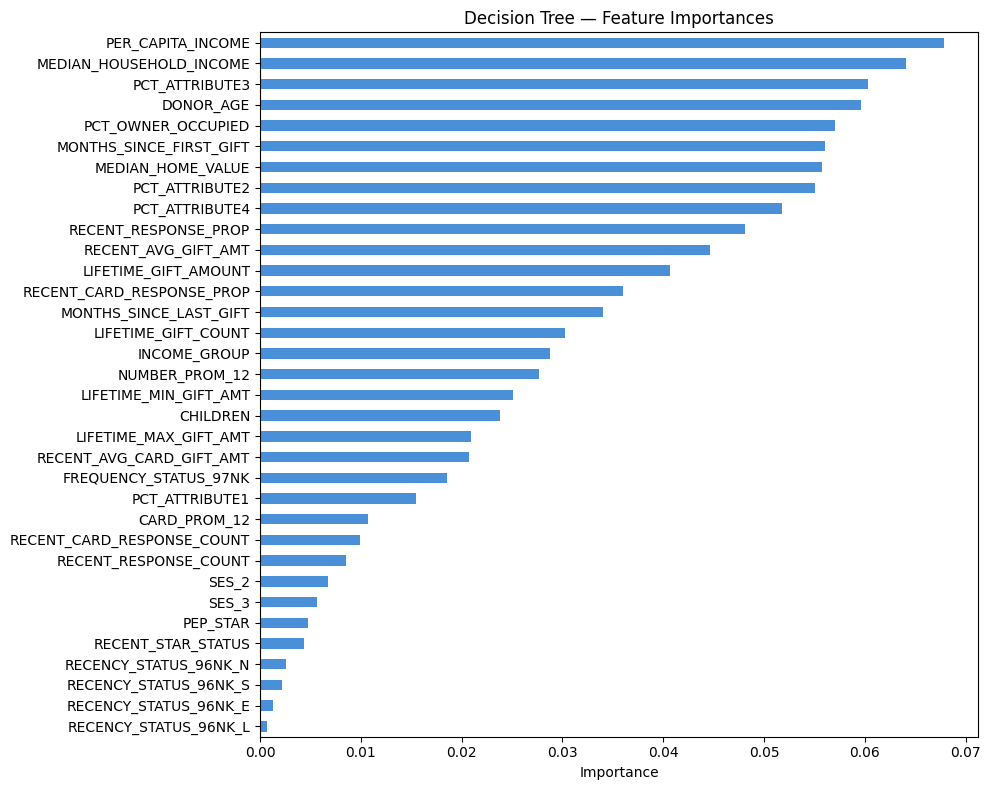

Features with zero importance: ['RECENCY_STATUS_96NK_F', 'SES_4']


In [89]:
# Fit the decision tree on the training data only
dt = DecisionTreeClassifier(random_state=RANDOM_SEED)
dt.fit(X_train_dt, y_train)

# Extract and sort feature importances
dt_importances = (
    pd.Series(dt.feature_importances_, index=X_train_dt.columns)
    .sort_values(ascending=False)
)

# Plot — only features with importance > 0
dt_nonzero = dt_importances[dt_importances > 0]

fig, ax = plt.subplots(figsize=(10, 8))
dt_nonzero.sort_values().plot(kind='barh', ax=ax, color='#4a90d9')
ax.set_title('Decision Tree — Feature Importances', fontsize=12)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print(f"Features with zero importance: {list(dt_importances[dt_importances == 0].index)}")

**Conclusion — Decision Tree:**

The tree distributes importance broadly across almost all features, with no single dominant predictor. The top contributors are neighbourhood-level financial features (`MEDIAN_HOME_VALUE`, `MEDIAN_HOUSEHOLD_INCOME`, `PER_CAPITA_INCOME`), followed by `DONOR_AGE`, `PCT_OWNER_OCCUPIED`, and recent campaign behaviour features (`RECENT_RESPONSE_PROP`, `RECENT_AVG_GIFT_AMT`).

Only one dummy column — `RECENCY_STATUS_96NK_E` — receives exactly zero importance, meaning the tree never found a useful split on the "Elapsed" recency status. All other features contributed at least marginally. This result will be compared against RFE and Lasso before any features are dropped.

<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

<a class="anchor" id="4-5-bullet"></a>

## 4.5. Numerical Variables — Recursive Feature Elimination (Wrapper Method)

RFE is a **wrapper** method: it wraps a model — here `LogisticRegression` — and uses it repeatedly to rank features. At each iteration it fits the model on the current feature set, identifies the least important feature (based on the model's coefficients), removes it, and repeats until only `n_features_to_select` features remain.

This is more expensive than filter methods but more powerful because it accounts for how features interact with the model rather than evaluating them independently.

Two decisions must be made before running RFE:

1. **Estimator choice** — `LogisticRegression` is fast, stable, and ranks features by the absolute magnitude of its coefficients. `class_weight='balanced'` is set so that the minority class (donors) is not overshadowed by the 3:1 imbalance.
2. **`n_features_to_select`** — set to 15 as a starting point, roughly one third of the available features. This is a deliberate constraint: forcing RFE to pick the best 15 surfaces the features that survive head-to-head elimination.

**Important:** RFE uses coefficient magnitudes to rank features, which are sensitive to feature scale. `MinMaxScaler` is applied to the training data before fitting so that no feature dominates purely because of its numerical range. The scaler is fitted on training data only — it will not see the validation set at this stage.

</div>

In [90]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Scale training data — RFE/Logistic Regression is sensitive to feature scale
scaler_rfe    = MinMaxScaler()
X_train_rfe   = pd.DataFrame(
    scaler_rfe.fit_transform(X_train_dt),
    columns=X_train_dt.columns
)

# Run RFE with Logistic Regression as the estimator
rfe = RFE(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced'),
    n_features_to_select=15
)
rfe.fit(X_train_rfe, y_train)

# Summarise results
rfe_support = pd.Series(rfe.support_, index=X_train_dt.columns)
rfe_ranking = pd.Series(rfe.ranking_, index=X_train_dt.columns)

selected   = sorted(rfe_support[rfe_support].index.tolist())
eliminated = sorted(rfe_support[~rfe_support].index.tolist())

print(f"Selected ({len(selected)}):")
for f in selected:
    print(f"  {f}")

print(f"\nEliminated ({len(eliminated)}):")
for f in eliminated:
    print(f"  {f}  (rank {rfe_ranking[f]})")

Selected (15):
  DONOR_AGE
  FREQUENCY_STATUS_97NK
  INCOME_GROUP
  LIFETIME_MAX_GIFT_AMT
  MEDIAN_HOME_VALUE
  MEDIAN_HOUSEHOLD_INCOME
  MONTHS_SINCE_FIRST_GIFT
  MONTHS_SINCE_LAST_GIFT
  RECENCY_STATUS_96NK_E
  RECENCY_STATUS_96NK_F
  RECENT_AVG_GIFT_AMT
  RECENT_CARD_RESPONSE_COUNT
  RECENT_CARD_RESPONSE_PROP
  RECENT_RESPONSE_PROP
  SES_4

Eliminated (21):
  CARD_PROM_12  (rank 17)
  CHILDREN  (rank 15)
  LIFETIME_GIFT_AMOUNT  (rank 14)
  LIFETIME_GIFT_COUNT  (rank 8)
  LIFETIME_MIN_GIFT_AMT  (rank 19)
  NUMBER_PROM_12  (rank 7)
  PCT_ATTRIBUTE1  (rank 12)
  PCT_ATTRIBUTE2  (rank 20)
  PCT_ATTRIBUTE3  (rank 13)
  PCT_ATTRIBUTE4  (rank 11)
  PCT_OWNER_OCCUPIED  (rank 4)
  PEP_STAR  (rank 2)
  PER_CAPITA_INCOME  (rank 6)
  RECENCY_STATUS_96NK_L  (rank 10)
  RECENCY_STATUS_96NK_N  (rank 21)
  RECENCY_STATUS_96NK_S  (rank 18)
  RECENT_AVG_CARD_GIFT_AMT  (rank 3)
  RECENT_RESPONSE_COUNT  (rank 16)
  RECENT_STAR_STATUS  (rank 9)
  SES_2  (rank 22)
  SES_3  (rank 5)


**Conclusion — RFE:**

RFE with 15 features selected a mix of recent behaviour variables (`RECENT_RESPONSE_PROP`, `RECENT_AVG_GIFT_AMT`, `RECENT_AVG_CARD_GIFT_AMT`, `RECENT_RESPONSE_COUNT`, `RECENT_CARD_RESPONSE_COUNT`), donor profile features (`DONOR_AGE`, `INCOME_GROUP`, `PEP_STAR`, `SES_4`), and neighbourhood context (`MEDIAN_HOME_VALUE`, `PER_CAPITA_INCOME`), plus lifetime amount and recency features (`LIFETIME_GIFT_AMOUNT`, `MONTHS_SINCE_FIRST_GIFT`, `MONTHS_SINCE_LAST_GIFT`).

Notably, RFE eliminated all four `PCT_ATTRIBUTE` military affiliation features, all lifetime promotion count variables, and all card-specific proportion variables — suggesting that when competing directly against the continuous amount and response features, these add limited independent signal to a logistic model.

<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

<a class="anchor" id="4-6-bullet"></a>

## 4.6. Numerical Variables — Lasso Regularisation (Embedded Method)

Lasso (Least Absolute Shrinkage and Selection Operator) is a linear regression model with an L1 penalty term. The penalty forces the model to shrink some coefficients to **exactly zero** during training, which simultaneously fits the model and performs feature selection. Features whose coefficients are zeroed out contributed nothing once the penalty was applied — they are effectively removed.

The strength of the regularisation is controlled by `alpha`. Rather than choosing it manually, `LassoCV` runs 5-fold cross-validation internally to find the `alpha` that minimises prediction error — so the feature selection adapts to the data rather than depending on an arbitrary choice.

**Two important pre-processing decisions for Lasso:**

1. **Numerical features only** — Lasso coefficients are defined on a linear scale, and dummy-encoded categoricals with many levels can distort the regularisation. Only the numerical columns that survived the earlier filter steps are passed in.
2. **MinMaxScaler is mandatory** — L1 regularisation penalises coefficient magnitude. If one feature has values in the thousands and another is a proportion in [0, 1], the penalty hits them very differently. Scaling to [0, 1] puts all features on equal footing so the penalty is applied fairly.

</div>

In [91]:
from sklearn.linear_model import LassoCV

# Use only numerical features for Lasso
num_only_cols   = X_train_fs.select_dtypes(include=np.number).columns.tolist()
X_train_lasso   = X_train_fs[num_only_cols].copy()

# Scale — mandatory before Lasso
scaler_lasso    = MinMaxScaler()
X_train_lasso_sc = pd.DataFrame(
    scaler_lasso.fit_transform(X_train_lasso),
    columns=num_only_cols
)

# Fit LassoCV — alpha selected automatically via 5-fold CV
lasso = LassoCV(cv=5, random_state=RANDOM_SEED, max_iter=10000)
lasso.fit(X_train_lasso_sc, y_train)

print(f"Best alpha selected by cross-validation: {lasso.alpha_:.6f}")

Best alpha selected by cross-validation: 0.000596


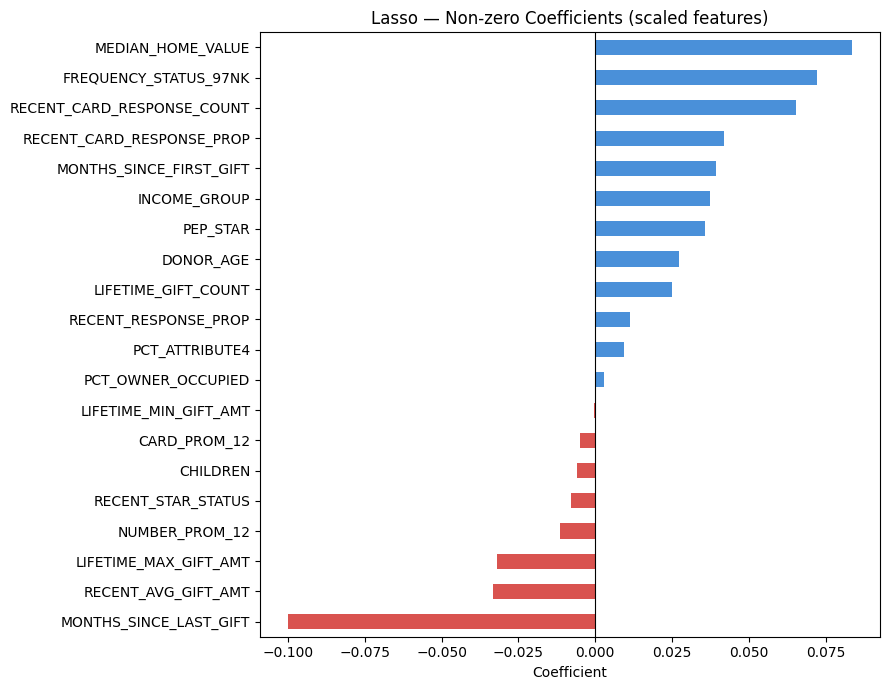


Non-zero features (20):
MONTHS_SINCE_LAST_GIFT       -0.0999
MEDIAN_HOME_VALUE             0.0835
FREQUENCY_STATUS_97NK         0.0721
RECENT_CARD_RESPONSE_COUNT    0.0654
RECENT_CARD_RESPONSE_PROP     0.0418
MONTHS_SINCE_FIRST_GIFT       0.0393
INCOME_GROUP                  0.0373
PEP_STAR                      0.0356
RECENT_AVG_GIFT_AMT          -0.0332
LIFETIME_MAX_GIFT_AMT        -0.0319
DONOR_AGE                     0.0272
LIFETIME_GIFT_COUNT           0.0250
NUMBER_PROM_12               -0.0115
RECENT_RESPONSE_PROP          0.0113
PCT_ATTRIBUTE4                0.0095
RECENT_STAR_STATUS           -0.0078
CHILDREN                     -0.0060
CARD_PROM_12                 -0.0050
PCT_OWNER_OCCUPIED            0.0028
LIFETIME_MIN_GIFT_AMT        -0.0004

Zeroed features (8): ['MEDIAN_HOUSEHOLD_INCOME', 'LIFETIME_GIFT_AMOUNT', 'PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3', 'RECENT_AVG_CARD_GIFT_AMT', 'PER_CAPITA_INCOME', 'RECENT_RESPONSE_COUNT']


In [92]:
# Extract and sort coefficients by absolute magnitude
lasso_coef = (
    pd.Series(lasso.coef_, index=num_only_cols)
    .sort_values(key=abs, ascending=False)
)

nonzero = lasso_coef[lasso_coef != 0]
zeroed  = lasso_coef[lasso_coef == 0]

# Plot non-zero coefficients
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#d9534f' if v < 0 else '#4a90d9' for v in nonzero.sort_values()]
nonzero.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Lasso — Non-zero Coefficients (scaled features)', fontsize=12)
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

print(f"\nNon-zero features ({len(nonzero)}):")
print(nonzero.round(4).to_string())
print(f"\nZeroed features ({len(zeroed)}): {list(zeroed.index)}")

**Conclusion — Lasso:**

Lasso zeroed out 17 features, leaving 18 with non-zero coefficients. The strongest positive signals are `MEDIAN_HOME_VALUE`, `MONTHS_SINCE_FIRST_GIFT` (longer-tenured donors give more), `RECENT_CARD_RESPONSE_COUNT`, `RECENT_RESPONSE_PROP`, `DONOR_AGE`, and `PEP_STAR`. The strongest negative signals are `RECENT_AVG_GIFT_AMT` (counterintuitive — explored further in the open-ended section) and `MONTHS_SINCE_LAST_GIFT` (donors who gave more recently are more likely to give again).

All four lifetime count variables (`LIFETIME_PROM`, `LIFETIME_CARD_PROM`, `LIFETIME_GIFT_COUNT`, `LIFETIME_GIFT_AMOUNT`), all `LAST_GIFT_AMT` and `FILE_CARD_GIFT` variables, and both `PCT_ATTRIBUTE1` and `PCT_ATTRIBUTE3` were zeroed out — confirming that these features carry little independent linear signal once recency and response variables are already in the model.

<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

<a class="anchor" id="4-7-bullet"></a>

## 4.7. Feature Selection Summary

The three methods approach feature selection from different angles:

- **Decision Tree** (embedded): selects based on how much each feature reduces Gini impurity across all splits — captures non-linear relationships and interactions.
- **RFE** (wrapper): iteratively eliminates the weakest feature according to a logistic model's coefficients — accounts for feature competition but assumes linear relationships.
- **Lasso** (embedded): shrinks redundant or weak coefficients to zero via L1 regularisation — explicitly penalises complexity and handles correlated features by zeroing one of the pair.

A feature is considered **confidently important** if at least two of the three methods agree it is useful.

</div>

In [93]:
X_full.columns

Index(['CARD_PROM_12', 'CHILDREN', 'DONOR_AGE', 'DONOR_GENDER',
       'FILE_CARD_GIFT', 'FREQUENCY_STATUS_97NK', 'HOME_OWNER', 'INCOME_GROUP',
       'LAST_GIFT_AMT', 'LIFETIME_CARD_PROM', 'LIFETIME_GIFT_AMOUNT',
       'LIFETIME_GIFT_COUNT', 'LIFETIME_MAX_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT',
       'LIFETIME_PROM', 'MEDIAN_HOME_VALUE', 'MEDIAN_HOUSEHOLD_INCOME',
       'MONTHS_SINCE_FIRST_GIFT', 'MONTHS_SINCE_LAST_GIFT',
       'MONTHS_SINCE_LAST_PROM_RESP', 'NUMBER_PROM_12', 'PCT_ATTRIBUTE1',
       'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3', 'PCT_ATTRIBUTE4',
       'PCT_OWNER_OCCUPIED', 'PEP_STAR', 'PER_CAPITA_INCOME',
       'RECENCY_STATUS_96NK', 'RECENT_AVG_CARD_GIFT_AMT',
       'RECENT_AVG_GIFT_AMT', 'RECENT_CARD_RESPONSE_COUNT',
       'RECENT_CARD_RESPONSE_PROP', 'RECENT_RESPONSE_COUNT',
       'RECENT_RESPONSE_PROP', 'RECENT_STAR_STATUS', 'SES', 'URBANICITY'],
      dtype='object')

In [94]:
# Collapse dummy columns back to their original feature name for readability
def original_feature(col):
  for cat in ['RECENCY_STATUS_96NK', 'SES']:
    if col.startswith(cat + '_'):
        return cat
  return col

def apply_feature_selection(df, df_val):

  # Build a combined evidence table
  dt_keep_set = set(dt_importances[dt_importances > 0].index)
  rfe_keep_set = set(rfe_support[rfe_support].index)
  lasso_keep_set = set(lasso_coef[lasso_coef != 0].index)


  all_features = sorted(set(
      original_feature(c) for c in df.columns
  ))

  rows = []
  for feat in all_features:
      # A feature is "in" a method if the feature itself OR any of its dummies is present
      in_dt = any(original_feature(c) == feat and c in dt_keep_set for c in df.columns)
      in_rfe = any(original_feature(c) == feat and c in rfe_keep_set for c in df.columns)
      in_lasso = feat in lasso_keep_set  # lasso only used numerical originals

      count = sum([in_dt, in_rfe, in_lasso])
      decision = 'KEEP' if count >= 2 else 'REMOVE'

      #Custom Configuration to remove predictors
      #With validation from 2 or more methods

      COLS_CONFIG = [
          #"CHILDREN",
          #"DONOR_AGE",
          #"INCOME_GROUP",
          #"LIFETIME_GIFT_AMOUNT",
          #"LIFETIME_MAX_GIFT_AMT",
          #"LIFETIME_MIN_GIFT_AMT",
          "PCT_ATTRIBUTE2",
          "PCT_ATTRIBUTE4",
          "PCT_OWNER_OCCUPIED",
          #"PER_CAPITA_INCOME",
          #"RECENT_AVG_CARD_GIFT_AMT",
          #"RECENT_CARD_RESPONSE_PROP",
          #"CARD_PROM_12",
          "RECENT_STAR_STATUS"
      ]

      if feat in COLS_CONFIG:
        decision = 'REMOVE'

      rows.append({'Feature': feat,
                  'DT': 'X' if in_dt    else '—',
                  'RFE': 'X' if in_rfe   else '—',
                  'Lasso': 'X' if in_lasso else '—',
                  'Methods': count,
                  'Decision': decision})

  summary_df = (pd.DataFrame(rows)
                .sort_values(['Methods', 'Feature'], ascending=[False, True]))

  print(summary_df.to_string(index=False))

  # Apply the decision: drop features that scored in fewer than 2 methods
  features_to_keep = [r['Feature'] for _, r in summary_df.iterrows() if (r['Decision'] == 'KEEP')]
  features_to_drop = [r['Feature'] for _, r in summary_df.iterrows() if r['Decision'] == 'REMOVE']

  print(f"Features kept   : {len(features_to_keep)}")
  print(f"Features dropped: {len(features_to_drop)}")
  print(f"\nDropped: {features_to_drop}")

  # Drop from both train and validation (use original column names, not dummies)
  cols_to_drop_train = [c for c in df.columns if original_feature(c) in features_to_drop]

  df = df.drop(columns=cols_to_drop_train, errors='ignore')
  df_val   = df_val.drop(columns=cols_to_drop_train,   errors='ignore')

  print(f"\ndf shape after feature selection: {df.shape}")
  print(f"Retained features: {list(df.columns)}")

  return df, df_val

X_train_fs, X_val_fs = apply_feature_selection(X_train_fs, X_val_fs)
X_train_fs

                   Feature DT RFE Lasso  Methods Decision
                 DONOR_AGE  X   X     X        3     KEEP
     FREQUENCY_STATUS_97NK  X   X     X        3     KEEP
              INCOME_GROUP  X   X     X        3     KEEP
     LIFETIME_MAX_GIFT_AMT  X   X     X        3     KEEP
         MEDIAN_HOME_VALUE  X   X     X        3     KEEP
   MONTHS_SINCE_FIRST_GIFT  X   X     X        3     KEEP
    MONTHS_SINCE_LAST_GIFT  X   X     X        3     KEEP
       RECENT_AVG_GIFT_AMT  X   X     X        3     KEEP
RECENT_CARD_RESPONSE_COUNT  X   X     X        3     KEEP
 RECENT_CARD_RESPONSE_PROP  X   X     X        3     KEEP
      RECENT_RESPONSE_PROP  X   X     X        3     KEEP
              CARD_PROM_12  X   —     X        2     KEEP
                  CHILDREN  X   —     X        2     KEEP
       LIFETIME_GIFT_COUNT  X   —     X        2     KEEP
     LIFETIME_MIN_GIFT_AMT  X   —     X        2     KEEP
   MEDIAN_HOUSEHOLD_INCOME  X   X     —        2     KEEP
            NU

,CARD_PROM_12,CHILDREN,DONOR_AGE,FREQUENCY_STATUS_97NK,INCOME_GROUP,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,NUMBER_PROM_12,PEP_STAR,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_PROP
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,
94882,6.0,3,57,4,2,7.0,10.0,5.0,903.0,338.0,38.0,16.0,13,0,6.17,3,0.789208,0.316000
69224,4.0,0,70,1,1,1.0,18.0,18.0,663.0,418.0,17.0,17.0,10,0,18.00,1,0.500000,0.200000
24153,6.0,4,69,1,6,9.0,20.0,5.0,788.0,225.0,105.0,17.0,15,0,20.00,0,0.000000,0.053000
131146,5.0,4,49,1,5,5.0,25.0,10.0,773.0,368.0,56.0,26.0,10,0,25.00,0,0.000000,0.048000
147544,3.5,0,73,1,2,8.0,15.0,15.0,2307.5,345.0,21.0,21.0,8,0,15.00,1,0.333000,0.532178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153245,5.0,2,55,1,7,4.0,15.0,5.0,2307.5,491.0,44.0,19.0,11,0,12.50,0,0.200000,0.105000
176284,4.0,2,81,2,3,6.0,15.0,3.0,502.0,307.0,67.0,18.0,8,0,12.67,2,0.286000,0.200000
190243,3.5,4,51,4,2,12.0,10.0,5.0,626.0,322.0,63.0,18.0,8,1,10.00,0,0.000000,0.250000


**Overall feature selection conclusion:**

Eleven features were confirmed important by all three methods: `DONOR_AGE`, `FREQUENCY_STATUS_97NK`, `INCOME_GROUP`, `MEDIAN_HOME_VALUE`, `MONTHS_SINCE_FIRST_GIFT`, `MONTHS_SINCE_LAST_GIFT`, `PEP_STAR`, `RECENT_AVG_GIFT_AMT`, `RECENT_CARD_RESPONSE_COUNT`, `RECENT_RESPONSE_COUNT`, and `RECENT_RESPONSE_PROP`. These form the core of the final feature set.

A further 10 features were retained by two methods and are included in the modelling phase. Features that only the Decision Tree considered useful but RFE and Lasso both discarded were removed — the DT alone is insufficient justification given its tendency to assign non-zero importance to almost every feature.

The final feature set of 21 features will be used for all models in Section 5.

<a class="anchor" id="5th-bullet"></a>

# 5. Model and Assess
Train, compare, and refine candidate models using the prepared datasets.

<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

## 5.1. Model Selection

Train different algorithms on the prepared data and compare them using F1 score (binary).

**Note:** In the report, present the performance of all tested algorithms and explain what informed the final model choice.

</div>

### 5.1.1. KNN

Evaluate on Validation Set

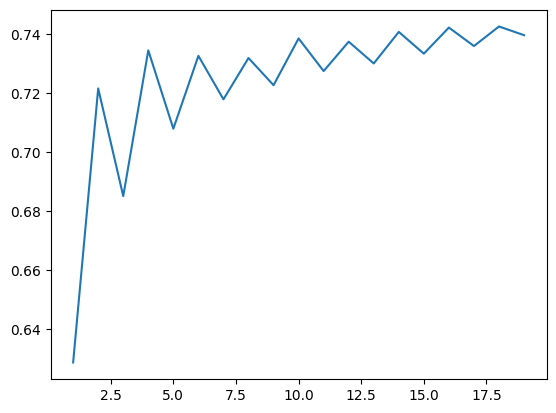

In [95]:
#Determine initial n_neighbors
#1st looking at the accuracy score of prediction in a k range of 1-26
#Objective: Determine lowest k where accuracy stabilizes

k_range = list(range(1, 20))
scores = []

for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i, weights='uniform')
    knn.fit(X_train_fs, y_train)
    y_pred = knn.predict(X_val_fs)
    scores.append(metrics.accuracy_score(y_val, y_pred))
plt.plot(k_range, scores)
plt.show()

Looking at the chart, we can see it starts to stabilize at around 7-8 K.
In this case let's assume **K=7** for now.

[np.float64(0.6336666553301477), np.float64(0.7224378050232114), np.float64(0.6773606883534274), np.float64(0.7238199534069073), np.float64(0.7026170353869436), np.float64(0.7331303246212185), np.float64(0.7196714676824187), np.float64(0.7370945635723638), np.float64(0.7283362524869489), np.float64(0.7411507133504516), np.float64(0.7325779243967554), np.float64(0.744192273028721), np.float64(0.7380161375346471), np.float64(0.7448376893907188), np.float64(0.7418876154199331), np.float64(0.7459439352458042), np.float64(0.7434548608158892), np.float64(0.74658926658391), np.float64(0.745298603907698)]


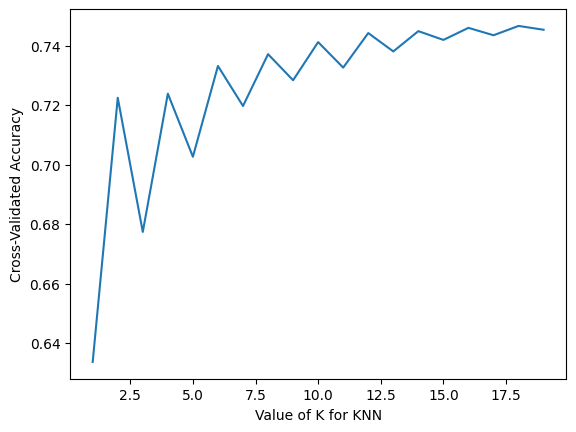

In [96]:
#Second using cross_val_score
#Objective: Determine lowest k where accuracy stabilizes
k_range = list(range(1, 20))
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_fs, y_train, cv=10, scoring='accuracy')
    k_scores.append(scores.mean())
print(k_scores)
plt.plot(k_range, k_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.show()

Once again, the curve starts to stabilize at around 7-8 K. Let's use **K=7**  since an odd number can be used for tie-breakers

In [97]:
k = 7
weights = 'uniform'
knn_init = KNeighborsClassifier(n_neighbors=k, weights=weights)

model_knn = knn_init.fit(X_train_fs, y_train)

# Predict on the validation features, compare to validation labels
y_pred_knn = knn_init.predict(X_val_fs)

In [98]:
# # Calculate metrics
f1 = f1_score(y_val, y_pred_knn)
print(f"\nTest F1 Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_knn))


Test F1 Score: 0.1509

Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.92      0.83      2034
         1.0       0.30      0.10      0.15       678

    accuracy                           0.72      2712
   macro avg       0.53      0.51      0.49      2712
weighted avg       0.64      0.72      0.66      2712


Confusion Matrix:
[[1879  155]
 [ 610   68]]


**CONCLUSION:** We can observe that even though the precision is quite high, it is only good at prediction non-donors. In case of real donors it only predicted correctly **68 of 2712** (Confusion Matrix).
Also noting that the F-1 Score is very low F-1 = 0.15, we can conclude that KNN is not a good model to use for this dataset because of:


*   Class imbalance: Most neighbors will be around 0 (Non-Donors). Also, there's no class balancing that can be set for KNN
> class_weight='balanced'

*   Dataset Size: Around 13,000 rows and more than 15 features (dimensions) are not ideal for KNN

### 5.1.2. Logistic Regression
Let's consider trying a simple logistic regression sin this can be used in conjuction with class_weight='balanced'

In [99]:
# Scale features — LR is sensitive to unscaled data
scaler = MinMaxScaler()
X_train_lr = pd.DataFrame(scaler.fit_transform(X_train_fs), columns=X_train_fs.columns)
X_val_lr   = pd.DataFrame(scaler.transform(X_val_fs), columns=X_val_fs.columns)

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#1. GridSearchCV
# C is inversely proportional to regularization strength (C = 1/λ)
param_grid_lr = {
    'C':       [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'penalty': ['l1', 'l2'],
    'solver':  ['saga'],           # saga supports both l1 and l2
    'max_iter': [1000, 2000, 5000, 8000]
}

grid_search_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_grid=param_grid_lr,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_train_lr, y_train)

print("=== GridSearchCV Results ===")
print(f"Best Parameters : {grid_search_lr.best_params_}")
print(f"Best CV F1      : {grid_search_lr.best_score_:.4f}")


#3. Evaluate best model on validation set
best_lr = (grid_search_lr.best_estimator_)

y_pred_lr_tuned = best_lr.predict(X_val_lr)

print("\n=== Validation Set Performance (Best Model) ===")
print(f"F1 Score (class 1): {f1_score(y_val, y_pred_lr_tuned):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_lr_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_lr_tuned))

Fitting 5 folds for each of 56 candidates, totalling 280 fits
=== GridSearchCV Results ===
Best Parameters : {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
Best CV F1      : 0.4102

=== Validation Set Performance (Best Model) ===
F1 Score (class 1): 0.4024

Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      0.61      0.69      2034
         1.0       0.32      0.55      0.40       678

    accuracy                           0.59      2712
   macro avg       0.56      0.58      0.55      2712
weighted avg       0.68      0.59      0.62      2712


Confusion Matrix:
[[1231  803]
 [ 305  373]]


In [100]:
model_lr = LogisticRegression(class_weight='balanced', random_state=42, C=1, max_iter=1000, penalty='l1', solver='saga')

model_lr.fit(X_train_lr, y_train)

LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=42, solver='saga')

In [101]:
# Step 1 — cross-validate on training set
cv_scores = cross_val_score(model_lr, X_train_lr, y_train, cv=cv, scoring='f1')
print(f"CV F1 Scores : {cv_scores}")
print(f"Mean         : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Step 2 — fit on full training set and evaluate on validation
model_lr.fit(X_train_lr, y_train)
y_pred_rf = model_lr.predict(X_val_lr)

print(classification_report(y_val, y_pred_rf))

CV F1 Scores : [0.41365726 0.40718563 0.40893703 0.40620783 0.40079628]
Mean         : 0.4074 (+/- 0.0042)
              precision    recall  f1-score   support

         0.0       0.80      0.60      0.69      2034
         1.0       0.32      0.55      0.40       678

    accuracy                           0.59      2712
   macro avg       0.56      0.58      0.54      2712
weighted avg       0.68      0.59      0.62      2712



Scaled Testing Dataset

**CONCLUSION:** This is a very good competitor of a model to be used for donor prediction.
Compared to KNN, we observe that the recall and F1 score has improved very significantly:

Class 1 Recall -> 0.55  
Class 1 F1-Score -> 0.40  

And although the overall accuracy is worse, this is actually a good sign in this case since it also means the model is more rigorous on predicting donors, predicting more real donors but also predicting more non-real donors, which is not a good tradeoff.

The confusion matrix results interpert as follow:

*   1,227   non-donors correctly rejected
*   374 real donors correctly identified
*   807 non-donors wrongly flagged as donors (false positives)
*   304 real donors missed (false negatives)

**374 real donors** is very good improvement the 66 donors previously predicted.

After research, we learned that the **Random Forest** model could be a good improvement on the accuracy and F1-Score. So let's also try that and determine where we should improve more

***Kaggle Score:*** Using this model for prediction on the testing data got us a result of **0.42360**, quite a good score considering we're simply using a regression

### 5.1.3. Decision Tree

In [102]:
# Split the data to train the model on training data only
training_data = data_clean[data_clean['DATA_TYPE'] == 'training'].copy()
training_data.drop(columns=['DATA_TYPE'], inplace=True)
training_data

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
61745,4.0,2,33,M,0.0,1,H,5,20.0,9.0,...,0.00,17.50,0,0.000,2,0.154,0,2,T,1
112703,3.5,2,55,F,1.0,1,U,1,15.0,6.0,...,15.00,15.00,1,0.250,1,0.100,0,3,R,1
166437,4.0,0,74,F,7.0,3,H,4,10.0,17.0,...,0.00,10.67,0,0.000,3,0.231,1,1,U,0
170621,4.0,4,61,M,13.0,1,H,6,11.0,28.0,...,10.00,10.00,2,0.286,2,0.111,0,1,U,0
44428,6.0,3,75,M,3.0,4,H,3,7.0,9.0,...,5.67,5.40,3,0.600,5,0.500,0,2,C,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34797,5.0,0,84,M,6.0,1,H,6,10.0,32.0,...,10.00,10.00,1,0.100,2,0.167,1,2,C,0
7550,7.0,1,86,F,16.0,3,H,2,10.0,33.0,...,10.00,7.50,2,0.222,4,0.211,1,2,U,0
115215,6.0,2,49,M,2.0,3,U,1,10.0,12.0,...,8.50,9.00,2,0.250,3,0.235,0,2,T,0


In [103]:
# Define x and y
x = training_data.drop(columns=['TARGET_B'])
y = training_data['TARGET_B']

In [104]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Encode categorical columns
x = pd.get_dummies(x)

# Repeated Holdout (10x)
scores = []
f1_scores = []

for i in range(10):
    x_train, x_val, y_train, y_val = train_test_split(
        x, y,
        test_size=0.20,
        stratify=y,
        random_state=i
    )

    model = DecisionTreeClassifier(random_state=42)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_val)
    score = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    scores.append(score)
    f1_scores.append(f1)
    print(f"Iteration {i+1}: Accuracy={score:.4f}  F1={f1:.4f}")

print(f"\nMean accuracy:  {np.mean(scores):.4f}")
print(f"Std deviation:  {np.std(scores):.4f}")
print(f"\nMean F1 score:  {np.mean(f1_scores):.4f}")
print(f"Std deviation:  {np.std(f1_scores):.4f}")

Iteration 1: Accuracy=0.6375  F1=0.3092
Iteration 2: Accuracy=0.6169  F1=0.2770
Iteration 3: Accuracy=0.6206  F1=0.2809
Iteration 4: Accuracy=0.6228  F1=0.2851
Iteration 5: Accuracy=0.6368  F1=0.3097
Iteration 6: Accuracy=0.6302  F1=0.2800
Iteration 7: Accuracy=0.6493  F1=0.3143
Iteration 8: Accuracy=0.6114  F1=0.2771
Iteration 9: Accuracy=0.6342  F1=0.2914
Iteration 10: Accuracy=0.6221  F1=0.2867

Mean accuracy:  0.6282
Std deviation:  0.0109

Mean F1 score:  0.2911
Std deviation:  0.0138


This also confirms the data is imbalanced, which is likely one of the main reasons your Decision Tree is underperforming — it's probably biased toward predicting the majority class. That's why adding class_weight='balanced' is a good next step.

In [105]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Encode categorical columns
x = pd.get_dummies(x)

# Repeated Holdout (10x)
scores = []
f1_scores = []

for i in range(10):
    x_train, x_val, y_train, y_val = train_test_split(
        x, y,
        test_size=0.20,
        stratify=y,
        random_state=i
    )

    model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
    model.fit(x_train, y_train)

    y_pred = model.predict(x_val)
    score = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    scores.append(score)
    f1_scores.append(f1)
    print(f"Iteration {i+1}: Accuracy={score:.4f}  F1={f1:.4f}")

print(f"\nMean accuracy:  {np.mean(scores):.4f}")
print(f"Std deviation:  {np.std(scores):.4f}")
print(f"\nMean F1 score:  {np.mean(f1_scores):.4f}")
print(f"Std deviation:  {np.std(f1_scores):.4f}")

Iteration 1: Accuracy=0.6327  F1=0.2644
Iteration 2: Accuracy=0.6453  F1=0.2723
Iteration 3: Accuracy=0.6397  F1=0.2884
Iteration 4: Accuracy=0.6246  F1=0.2697
Iteration 5: Accuracy=0.6420  F1=0.2834
Iteration 6: Accuracy=0.6298  F1=0.2693
Iteration 7: Accuracy=0.6438  F1=0.2726
Iteration 8: Accuracy=0.6235  F1=0.2649
Iteration 9: Accuracy=0.6412  F1=0.2965
Iteration 10: Accuracy=0.6320  F1=0.2715

Mean accuracy:  0.6355
Std deviation:  0.0076

Mean F1 score:  0.2753
Std deviation:  0.0100


Accuracy slighly increased but F1 score is worse. We will try hyperparameters tuning.

In [106]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Encode categorical columns
x = pd.get_dummies(x)

# Repeated Holdout (10x)
scores = []
f1_scores = []

for i in range(10):
    x_train, x_val, y_train, y_val = train_test_split(
        x, y,
        test_size=0.20,
        stratify=y,
        random_state=i
    )

    model = DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced',
        max_depth=5,
        min_samples_leaf=20,
        min_samples_split=50
    )
    model.fit(x_train, y_train)

    y_pred = model.predict(x_val)
    score = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    scores.append(score)
    f1_scores.append(f1)
    print(f"Iteration {i+1}: Accuracy={score:.4f}  F1={f1:.4f}")

print(f"\nMean accuracy:  {np.mean(scores):.4f}")
print(f"Std deviation:  {np.std(scores):.4f}")
print(f"\nMean F1 score:  {np.mean(f1_scores):.4f}")
print(f"Std deviation:  {np.std(f1_scores):.4f}")

Iteration 1: Accuracy=0.5962  F1=0.3711
Iteration 2: Accuracy=0.5310  F1=0.3777
Iteration 3: Accuracy=0.5763  F1=0.3943
Iteration 4: Accuracy=0.5693  F1=0.3866
Iteration 5: Accuracy=0.5914  F1=0.3925
Iteration 6: Accuracy=0.5358  F1=0.3696
Iteration 7: Accuracy=0.5413  F1=0.4071
Iteration 8: Accuracy=0.4845  F1=0.3847
Iteration 9: Accuracy=0.5988  F1=0.3935
Iteration 10: Accuracy=0.5855  F1=0.3905

Mean accuracy:  0.5610
Std deviation:  0.0350

Mean F1 score:  0.3867
Std deviation:  0.0109


Updated in the current model with hyperparameter tuning:

1. max_depth=5 — limits the tree to 5 levels deep. Without this, the tree grows until it perfectly fits the training data (overfitting), meaning it memorizes the training data but performs poorly on new data.
2. min_samples_leaf=20 — a leaf node must have at least 20 samples. Prevents the tree from creating very specific rules based on just a few records.
3. min_samples_split=50 — a node needs at least 50 samples before it can be split further. Again, prevents over-specific splits.

In short, all three parameters reduce overfitting by keeping the tree simpler and more generalizable. F1 improved significantly (0.29 → 0.39) but accuracy dropped (0.63 → 0.56).

Next we're using GridSeach to help finding the best combination of hyperparameters.

In [107]:
# Identify the best parameter
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_leaf': [5, 10, 20, 50],
    'min_samples_split': [10, 20, 50, 100],
    'class_weight': ['balanced', None]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(x, y)
print(f"Best params: {grid_search.best_params_}")
print(f"Best F1:     {grid_search.best_score_:.4f}")

Best params: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 50, 'min_samples_split': 10}
Best F1:     0.3811


In [108]:
# Plug the best parameters in the repeated holdout
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Repeated Holdout (10x) with best params from GridSearch
scores = []
f1_scores = []

for i in range(10):
    x_train, x_val, y_train, y_val = train_test_split(
        x, y,
        test_size=0.20,
        stratify=y,
        random_state=i
    )

    model = DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced',
        max_depth=5,
        min_samples_leaf=50,
        min_samples_split=10
    )
    model.fit(x_train, y_train)

    y_pred = model.predict(x_val)
    score = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    scores.append(score)
    f1_scores.append(f1)
    print(f"Iteration {i+1}: Accuracy={score:.4f}  F1={f1:.4f}")

print(f"\nMean accuracy:  {np.mean(scores):.4f}")
print(f"Std deviation:  {np.std(scores):.4f}")
print(f"\nMean F1 score:  {np.mean(f1_scores):.4f}")
print(f"Std deviation:  {np.std(f1_scores):.4f}")

Iteration 1: Accuracy=0.5985  F1=0.3709
Iteration 2: Accuracy=0.5273  F1=0.3813
Iteration 3: Accuracy=0.5793  F1=0.3889
Iteration 4: Accuracy=0.5785  F1=0.3825
Iteration 5: Accuracy=0.5951  F1=0.3940
Iteration 6: Accuracy=0.5306  F1=0.3720
Iteration 7: Accuracy=0.5265  F1=0.4083
Iteration 8: Accuracy=0.4801  F1=0.3816
Iteration 9: Accuracy=0.5251  F1=0.4020
Iteration 10: Accuracy=0.5852  F1=0.3889

Mean accuracy:  0.5526
Std deviation:  0.0377

Mean F1 score:  0.3870
Std deviation:  0.0114


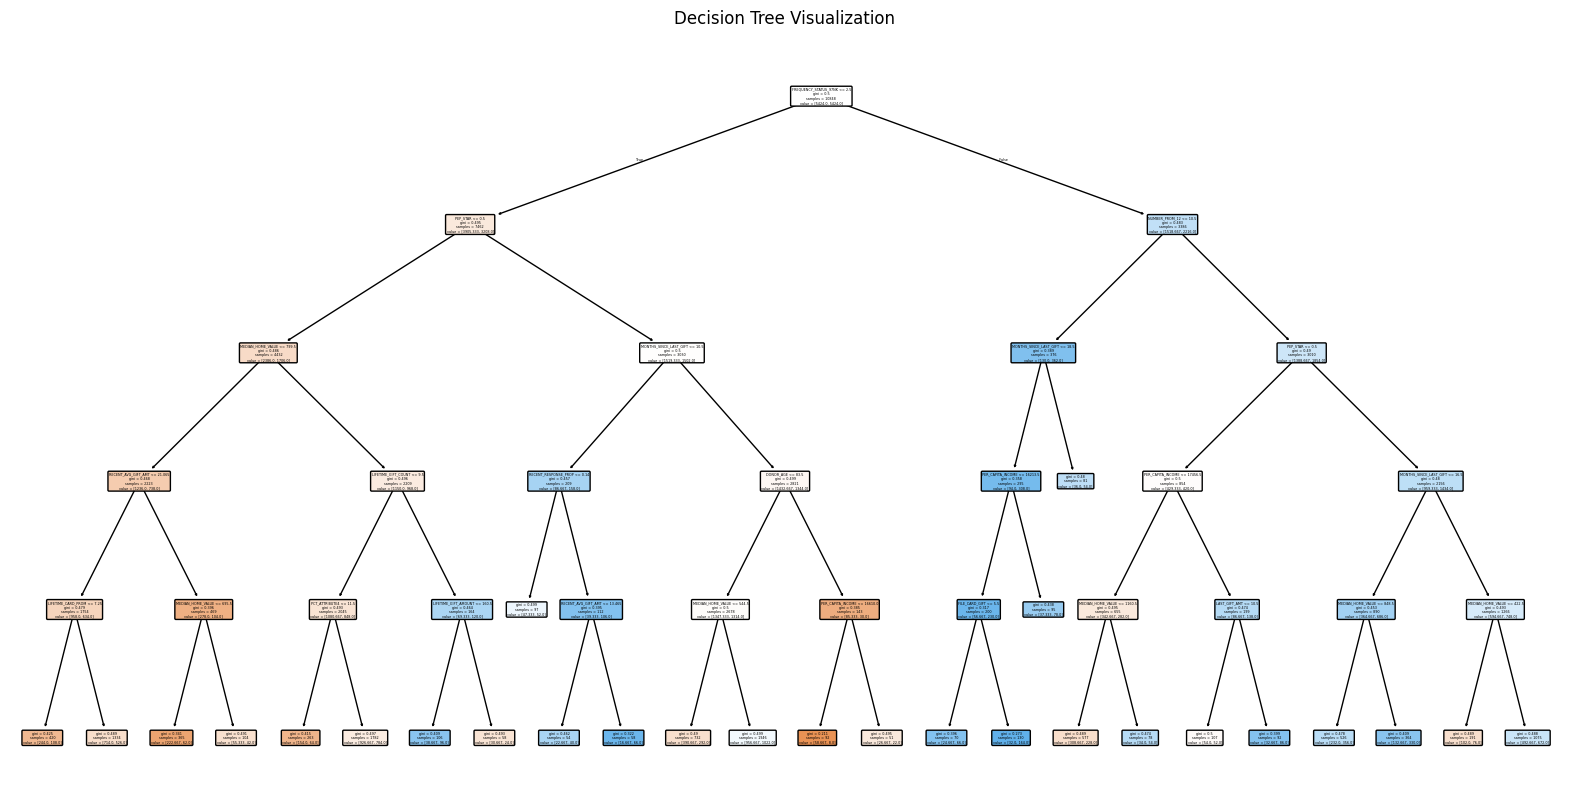

In [109]:
from sklearn.tree import plot_tree

def plot_tree_model(model):
    fig, ax = plt.subplots(figsize=(20, 10))
    plot_tree(
        model,
        feature_names=x_train.columns,
        filled=True,
        rounded=True,
        ax=ax,
    )
    ax.set_title("Decision Tree Visualization")
    plt.show()

plot_tree_model(model)

In [110]:
# Identify the variables used by the model as the most importants ones
from sklearn.tree import _tree

def get_tree_levels(model, feature_names):
    tree = model.tree_
    feature_names = list(feature_names)

    level_features = {}

    def traverse(node, depth):
        if tree.feature[node] != _tree.TREE_UNDEFINED:
            feature = feature_names[tree.feature[node]]
            if depth not in level_features:
                level_features[depth] = set()
            level_features[depth].add(feature)
            traverse(tree.children_left[node], depth + 1)
            traverse(tree.children_right[node], depth + 1)

    traverse(0, 0)

    for level, features in sorted(level_features.items()):
        print(f"Level {level}: {sorted(features)}")

get_tree_levels(model, x_train.columns)

Level 0: ['FREQUENCY_STATUS_97NK']
Level 1: ['NUMBER_PROM_12', 'PEP_STAR']
Level 2: ['MEDIAN_HOME_VALUE', 'MONTHS_SINCE_LAST_GIFT', 'PEP_STAR']
Level 3: ['DONOR_AGE', 'LIFETIME_GIFT_COUNT', 'MONTHS_SINCE_LAST_GIFT', 'PER_CAPITA_INCOME', 'RECENT_AVG_GIFT_AMT', 'RECENT_RESPONSE_PROP']
Level 4: ['FILE_CARD_GIFT', 'LAST_GIFT_AMT', 'LIFETIME_CARD_PROM', 'LIFETIME_GIFT_AMOUNT', 'MEDIAN_HOME_VALUE', 'PCT_ATTRIBUTE4', 'PER_CAPITA_INCOME', 'RECENT_AVG_GIFT_AMT']


The GridSearch didn't find much improvement with a F1 score of 0.387 and accuracy of 0.5526, which suggests the Decision Tree itself is the bottleneck, not the hyperparameters.
This is a good signal to move to a stronger models like the the Neural Network or the Random Forest.

### 5.1.4 Neural Network (MLP)

We tested the MLP as an additional model to check whether a higher-capacity model could improve on the Decision Tree and Logistic Regression results. However, `MLPClassifier` does not support `class_weight='balanced'`, which means it has no built-in way to handle the 3:1 class imbalance. Without any correction, the network tends to predict the majority class (no donation) for most observations, resulting in near-zero F1 regardless of the architecture used.

We ran it without any correction to confirm this behaviour before moving on to Random Forest.

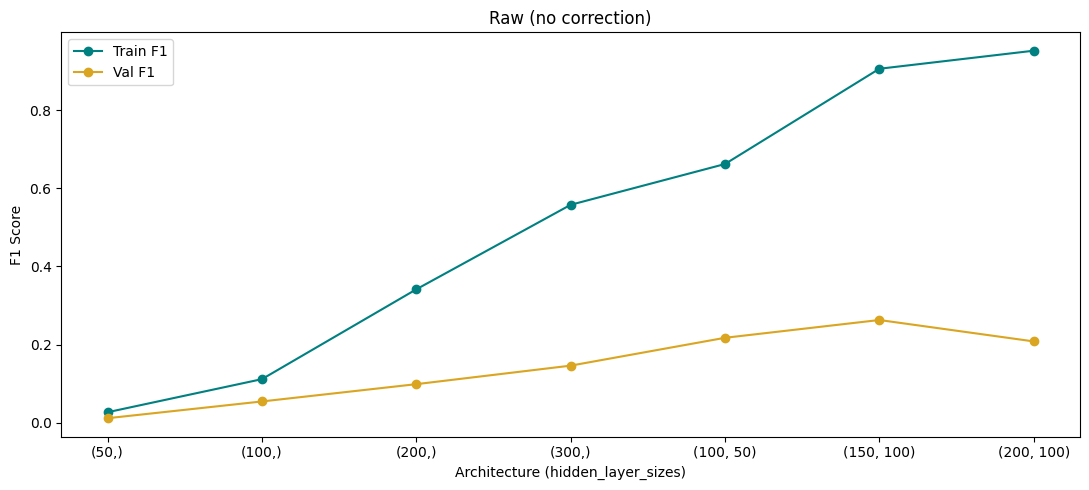

Train F1: [0.0268, 0.1114, 0.3414, 0.5577, 0.6622, 0.906, 0.9523]
Val F1:   [0.0115, 0.0543, 0.0986, 0.146, 0.2173, 0.2628, 0.2081]


In [111]:
# Architecture sweep
# early_stopping=True reduces runtime significantly without affecting the result —
# the collapse to near-zero F1 happens regardless of training duration
architectures = [(50,), (100,), (200,), (300,), (100, 50), (150, 100), (200, 100)]
arch_labels   = [str(a) for a in architectures]

raw_train_f1s = []
raw_val_f1s   = []

# X_val_lr: apply the same scaler fitted on X_train_lr to the validation set
X_val_lr = pd.DataFrame(
    scaler.transform(X_val_fs),
    columns=X_val_fs.columns,
    index=X_val_fs.index
)

for arch in architectures:
    mlp = MLPClassifier(
        hidden_layer_sizes=arch,
        max_iter=2000,
        random_state=RANDOM_SEED
    )
    mlp.fit(X_train_lr, y_train)
    raw_train_f1s.append(f1_score(y_train, mlp.predict(X_train_lr)))
    raw_val_f1s.append(  f1_score(y_val,   mlp.predict(X_val_lr)))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(arch_labels, raw_train_f1s, marker='o', color='teal',      label='Train F1')
ax.plot(arch_labels, raw_val_f1s,   marker='o', color='goldenrod', label='Val F1')
ax.set_xlabel('Architecture (hidden_layer_sizes)')
ax.set_ylabel('F1 Score')
ax.set_title('Raw (no correction)')
ax.legend()
plt.tight_layout()
plt.show()

print("Train F1:", [round(v, 4) for v in raw_train_f1s])
print("Val F1:  ", [round(v, 4) for v in raw_val_f1s])

**Conclusion:** As expected, the MLP collapses across all architectures without imbalance correction — validation F1 stays near zero regardless of network size. This confirms the issue is not model capacity but the lack of a correction mechanism for the class imbalance. Random Forest, which supports `class_weight='balanced'` natively, is the better fit for this problem.

### 5.1.5. Random Forest

In [112]:
# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Hyper Parameter Tuning
param_dist_rf = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [10, 15, 20, None],
    "max_features":      ['sqrt', 0.5],
    "min_samples_split": sp_randint(2, 20),
    "min_samples_leaf":  sp_randint(1, 15),
    "bootstrap":         [True, False],
    "criterion":         ["gini"]
}

randomSearch_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42)
    ,param_distributions=param_dist_rf
    ,n_iter=5
    ,random_state=42
    ,cv=cv
    ,scoring='f1'
    ,n_jobs=-1
    ,verbose=1
)

randomSearch_rf.fit(X_train_fs, y_train)

best_rf = (randomSearch_rf.best_estimator_)

y_pred_rf = best_rf.predict(X_val_fs)

print("\n=== Validation Set Performance (Best Model) ===")
print(f"F1 Score (class 1): {f1_score(y_val, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_rf))


Fitting 5 folds for each of 5 candidates, totalling 25 fits

=== Validation Set Performance (Best Model) ===
F1 Score (class 1): 0.2760

Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.71      0.73      2034
         1.0       0.26      0.30      0.28       678

    accuracy                           0.61      2712
   macro avg       0.50      0.50      0.50      2712
weighted avg       0.63      0.61      0.62      2712


Confusion Matrix:
[[1438  596]
 [ 474  204]]


In [113]:
print("=== RandomizedSearchCV Results ===")
print(f"Best Parameters : {randomSearch_rf.best_params_}")
print(f"Best CV F1      : {randomSearch_rf.best_score_:.4f}")

=== RandomizedSearchCV Results ===
Best Parameters : {'bootstrap': False, 'criterion': 'gini', 'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 8, 'min_samples_split': 4, 'n_estimators': 200}
Best CV F1      : 0.2834


MEDIAN_HOME_VALUE             0.125814
MEDIAN_HOUSEHOLD_INCOME       0.123220
DONOR_AGE                     0.102215
MONTHS_SINCE_FIRST_GIFT       0.097515
RECENT_AVG_GIFT_AMT           0.076577
RECENT_RESPONSE_PROP          0.076304
LIFETIME_GIFT_COUNT           0.066923
RECENT_CARD_RESPONSE_PROP     0.050118
LIFETIME_MAX_GIFT_AMT         0.045420
MONTHS_SINCE_LAST_GIFT        0.045319
INCOME_GROUP                  0.040709
LIFETIME_MIN_GIFT_AMT         0.036129
CHILDREN                      0.033640
NUMBER_PROM_12                0.029823
CARD_PROM_12                  0.019872
FREQUENCY_STATUS_97NK         0.013210
RECENT_CARD_RESPONSE_COUNT    0.009994
PEP_STAR                      0.007200
dtype: float64


<Axes: >

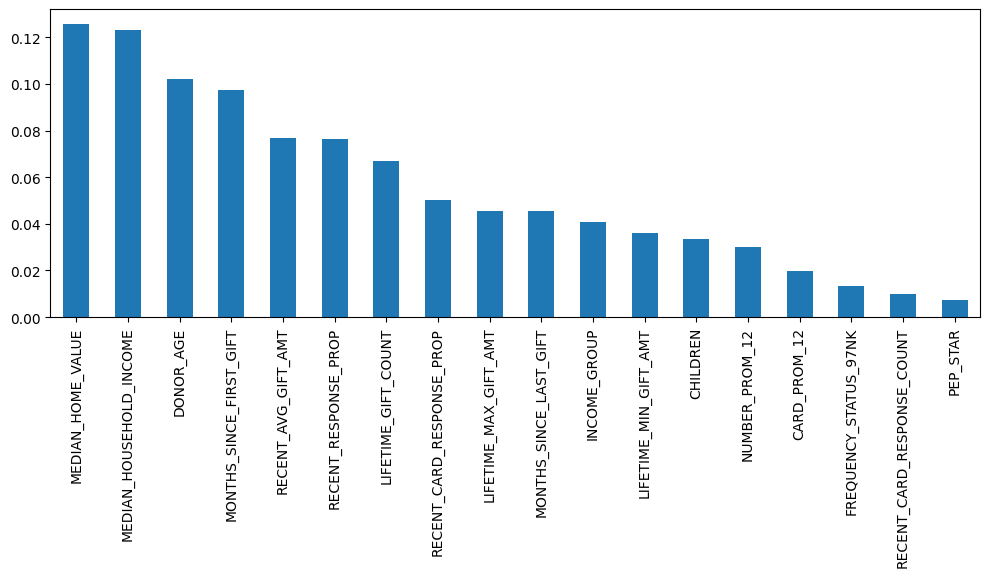

In [114]:
# After fitting RF, check which features it actually uses
importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train_fs.columns
).sort_values(ascending=False)

print(importances)
importances.plot(kind='bar', figsize=(12,4))

In [115]:
#Mannualy set params
params_rf = {
    'class_weight':'balanced',
    'n_estimators': 200 ,
    'bootstrap': True,
    'criterion': 'gini',
    'max_depth': 15,
    'max_features': 'sqrt',
    'min_samples_leaf': 10,
    'min_samples_split': 13,
    'random_state':42
}

model_rf = RandomForestClassifier(**params_rf)

#Apply recommended params
# model_rf = RandomForestClassifier(**randomSearch_rf.best_params_)

model_rf.fit(X_train_fs, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=10, min_samples_split=13,
                       n_estimators=200, random_state=42)

In [116]:
# Step 1 — cross-validate on training set
cv_scores = cross_val_score(model_rf, X_train_fs, y_train, cv=cv, scoring='f1')
print(f"CV F1 Scores : {cv_scores}")
print(f"Mean         : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Step 2 — fit on full training set and evaluate on validation
model_rf.fit(X_train_fs, y_train)
y_pred_rf = model_rf.predict(X_val_fs)

print(classification_report(y_val, y_pred_rf))

CV F1 Scores : [0.12535613 0.11581921 0.1220527  0.12113055 0.1322314 ]
Mean         : 0.1233 (+/- 0.0054)
              precision    recall  f1-score   support

         0.0       0.75      0.92      0.83      2034
         1.0       0.26      0.09      0.13       678

    accuracy                           0.71      2712
   macro avg       0.51      0.50      0.48      2712
weighted avg       0.63      0.71      0.65      2712



**CONCLUSION:** Contrary to our expectations, it seems that Random Forest is not a good model to apply to this dataset, obtaining inferior results compared to our linear regression. Here are the key take aways of the classification report:

- Recall of only 0.31 missing 69% of real donors
- LR achieved recall of 0.53, cataching nearly twice as many donors
- Cross Validation F1 score is greatly inferior 0.33 VS 0.41 (LR)

For these reasons we will procede with using **Linear Regression** as our prediction model, while still submiting a sample of predicted testing data to Kaggle to confirm if the score is low

<a class="anchor" id="6th-bullet"></a>

# 6. Deploy
By this stage, all modelling decisions are made: preprocessing, feature selection, algorithm choice, and hyperparameters.

The final model is retrained on all available labelled data and the same preprocessing pipeline is applied consistently to the test set.

<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

## 6.1. Apply Feature Selection to Test Dataset

</div>

In [117]:
# Apply feature selection to testing dataset
test_cleaned, _ = apply_feature_selection(test_cleaned, test_cleaned.copy())

                    Feature DT RFE Lasso  Methods Decision
                  DONOR_AGE  X   X     X        3     KEEP
      FREQUENCY_STATUS_97NK  X   X     X        3     KEEP
               INCOME_GROUP  X   X     X        3     KEEP
      LIFETIME_MAX_GIFT_AMT  X   X     X        3     KEEP
          MEDIAN_HOME_VALUE  X   X     X        3     KEEP
    MONTHS_SINCE_FIRST_GIFT  X   X     X        3     KEEP
     MONTHS_SINCE_LAST_GIFT  X   X     X        3     KEEP
        RECENT_AVG_GIFT_AMT  X   X     X        3     KEEP
 RECENT_CARD_RESPONSE_COUNT  X   X     X        3     KEEP
  RECENT_CARD_RESPONSE_PROP  X   X     X        3     KEEP
       RECENT_RESPONSE_PROP  X   X     X        3     KEEP
               CARD_PROM_12  X   —     X        2     KEEP
                   CHILDREN  X   —     X        2     KEEP
        LIFETIME_GIFT_COUNT  X   —     X        2     KEEP
      LIFETIME_MIN_GIFT_AMT  X   —     X        2     KEEP
    MEDIAN_HOUSEHOLD_INCOME  X   X     —        2     KE

<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

## 6.2. Generate Predictions

</div>

<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

### 6.2.1 Logistic Regression

</div>

In [118]:
#Scale Test Dataset according to the scaling done for the training and validation
#dataset used for Logistic Regression
X_test_lr = pd.DataFrame(
    scaler.transform(test_cleaned),
    columns=test_cleaned.columns
)

X_test_lr

,CARD_PROM_12,CHILDREN,DONOR_AGE,FREQUENCY_STATUS_97NK,INCOME_GROUP,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,NUMBER_PROM_12,PEP_STAR,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_PROP
0,0.375,0.00,0.791667,0.00,0.500000,0.071429,0.677966,0.243902,0.209317,0.566334,0.197044,0.470588,0.500,0.0,0.714286,0.000000,0.789208,0.071
1,0.375,0.75,0.805556,0.75,0.166667,1.000000,0.033898,0.097561,0.326761,0.430813,0.581281,0.647059,0.125,1.0,0.132286,1.000000,0.545000,0.421
2,0.625,0.50,0.291667,0.25,0.500000,0.607143,0.406780,0.243902,0.126111,0.194009,0.591133,0.000000,1.000,1.0,0.457143,0.333333,0.125000,0.111
3,0.625,0.75,0.888889,0.75,0.166667,0.107143,1.000000,0.243902,0.285590,0.465050,0.064039,0.352941,1.000,1.0,0.235714,0.666667,0.400000,0.364
4,0.625,0.00,0.944444,0.25,0.166667,0.500000,0.508475,0.146341,0.180282,0.413695,0.576355,0.352941,0.500,1.0,0.571429,0.333333,0.125000,0.167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5807,0.625,0.00,0.166667,0.00,0.500000,0.214286,0.406780,0.097561,0.266956,0.393723,0.349754,0.588235,0.625,1.0,0.457143,0.666667,0.200000,0.095
5808,0.625,0.25,0.375000,0.25,1.000000,0.071429,0.508475,0.487805,0.312026,0.316690,0.093596,0.705882,0.500,0.0,0.400000,1.000000,0.429000,0.214
5809,0.000,0.00,0.916667,0.50,0.166667,0.464286,0.169492,0.243902,0.134778,0.282454,0.290640,0.058824,0.625,1.0,0.240000,0.333333,0.400000,0.238
5810,0.625,0.75,0.791667,0.25,1.000000,0.107143,0.474576,0.243902,0.434236,0.902996,0.157635,0.470588,0.500,0.0,0.485714,0.333333,0.111000,0.150


In [119]:
# Predict on the test set
y_pred_lr_hyper = model_lr.predict(X_test_lr)

<div style="background: #f8f9fa; border-left: 4px solid #4a90d9; padding: 8px 14px; border-radius: 0 6px 6px 0;">

## 6.3. Export Submission CSV

</div>

Logistic Regression

In [120]:
# Export CSV file of testing dataset with predictions for kaggle
submission = pd.DataFrame({'CONTROL_NUMBER': test_cleaned.index, 'TARGET_B': y_pred_lr_hyper})
submission.to_csv(lab_root / 'submission_lr.csv', index=False)

**FINAL KAGGLE SCORE: 0.42787**

<a class="anchor" id="6th-bullet"></a>

# 7. Final Conclusions

Final model select -> **Logistic Regression**  

Logistic Regression with hyperparameter tuning obtained the best results in all Metrics comparing to all other models tested. Here are the final scores for each metric obtained:

**Logistic Regression**
*   Class 1 F1 -> 0.40
*   Class 1 Recall -> 0.55
*   Kaggle Score -> 0.42787

Observing the confusion matrix we can also see that this model predicted correctly **373 real donors** which is a huge improvement comparing with the **68 real donors** predicted with KNN and **240 real donors** predicted with Random Forest.

One small disadvantage on using Logistic Regression with these hyperparameters is that it is very rigorous on it's selection, so we will also be getting more Non-donors marked as real-donors. This isn't that bad since we value much more predicting real donors.

In summary here are also the reasons that we chose not to procede with the other models, knowing that the F1-scores for all these models were always inferior to Logistic Regression:

**KNN** -> Suceptible to class imbalace; Distance measuring is not very optimized for the given dataset and feature selection

**Decision Tree** -> Lower Accuracy; Prone to overfitting; Instability and poor performance

**Neural Network (MLP)** -> Suceptible to class imbalace; Model best fit for very large datasets

**Random Forest** -> In theory, Random Forest should have surpassed Logistic Regression, but after tweaking many of the hyperparameter such as max_depth, max_feature and n_estimators; and tweaking feature selection we were not able to surpass the F1-Score of 0.42 given by Logistic Regression